# This is the codes for Quantitative Risk Management Coursework.
The group members are Zhengyang Li, Fiona Lemon, Thomas Pink and Jacques Zhang.

In [2]:
# Question 1

In [2]:
import pandas as pd
import numpy as np 
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

SX5E = pd.read_csv('QRM-2024-cw1-data-a.csv')
display(SX5E.head())
display(SX5E.tail())


,Date,Adj Close
0,30/10/2013,3040.689941
1,31/10/2013,3067.949951
2,01/11/2013,3052.139893
3,04/11/2013,3061.179932
4,05/11/2013,3035.919922


,Date,Adj Close
2507,23/10/2023,4041.750000
2508,24/10/2023,4065.370117
2509,25/10/2023,4073.350098
2510,26/10/2023,4049.399902
2511,27/10/2023,4014.360107


In [3]:
SX5E['simplereturn'] = SX5E['Adj Close'].pct_change()
SX5E['simplereturn2'] = (SX5E['Adj Close'] - SX5E['Adj Close'].shift(1)) / SX5E['Adj Close'].shift(1)
SX5E['logreturn'] = np.log(1 + SX5E['simplereturn'])

# multiply the return values by 100 for percentage values
SX5E['simplereturn']  = SX5E['simplereturn']  * 100
SX5E['simplereturn2']  = SX5E['simplereturn2']  * 100
SX5E['logreturn'] = SX5E['logreturn'] * 100

SX5E.head()

/var/folders/55/4gwk10js6q79qy735qxj53m00000gn/T/ipykernel_37108/2182269772.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  SX5E['simplereturn'] = SX5E['Adj Close'].pct_change()


,Date,Adj Close,simplereturn,simplereturn2,logreturn
0,30/10/2013,3040.689941,NaN,NaN,NaN
1,31/10/2013,3067.949951,0.896507,0.896507,0.892513
2,01/11/2013,3052.139893,-0.515330,-0.515330,-0.516662
3,04/11/2013,3061.179932,0.296187,0.296187,0.295749
4,05/11/2013,3035.919922,-0.825172,-0.825172,-0.828596


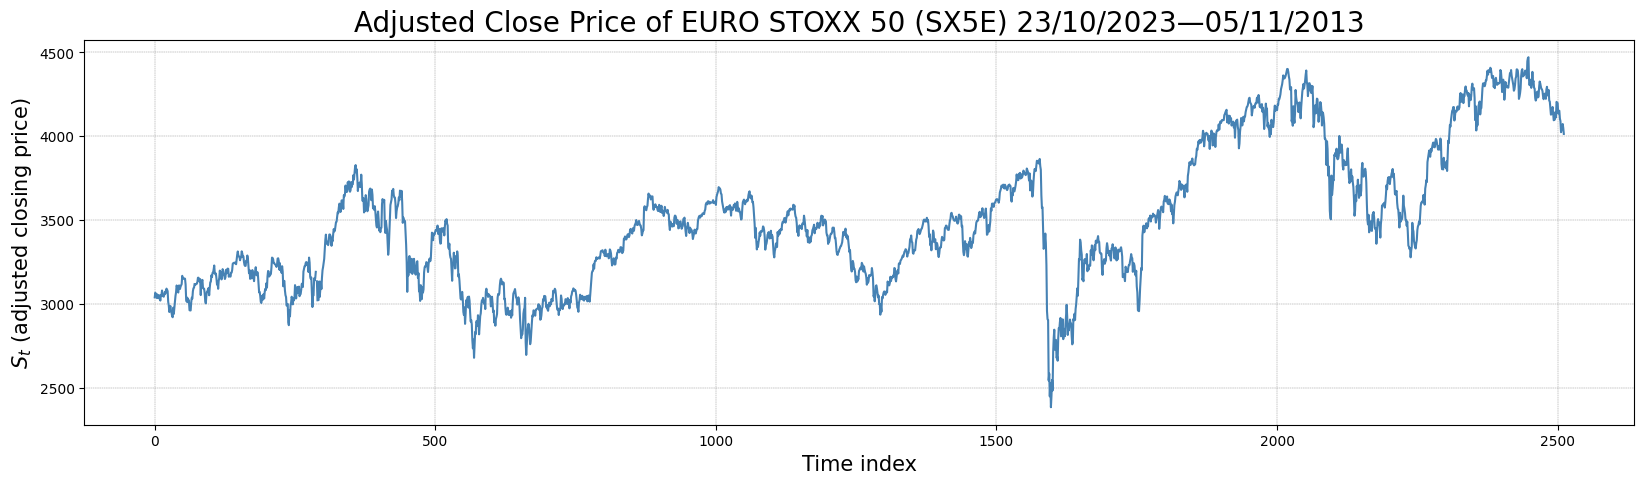

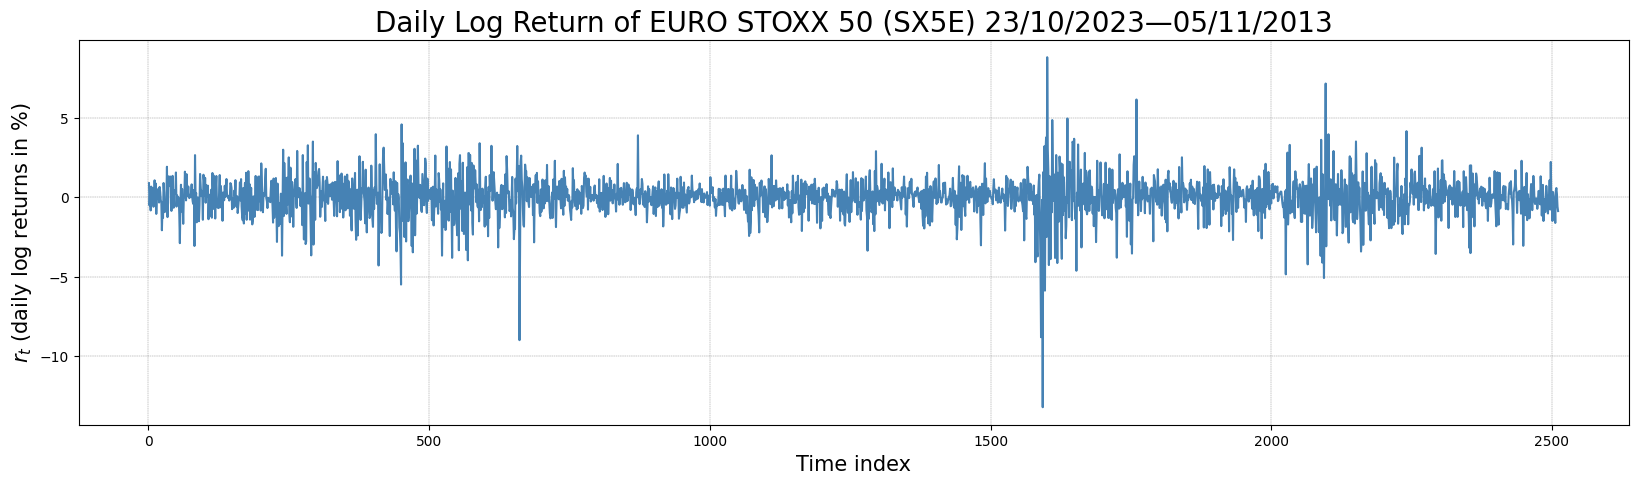

In [5]:
plt.figure(figsize=(20,5))
plt.plot(SX5E['Adj Close'], color = '#4682b4')
plt.ylabel(r"$S_t$ (adjusted closing price)", fontsize = 15)
plt.xlabel('Time index', fontsize=15)
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.gcf().set_facecolor("white")
plt.title(r"Adjusted Close Price of EURO STOXX 50 (SX5E) 23/10/2023—05/11/2013", fontsize=20)
plt.show()

plt.figure(figsize=(20,5))
plt.plot(SX5E['logreturn'], color = '#4682b4')
plt.ylabel(r"$r_t$ (daily log returns in %)", fontsize=15)
plt.xlabel('Time index', fontsize=15)
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.gcf().set_facecolor("white")
plt.title(r"Daily Log Return of EURO STOXX 50 (SX5E) 23/10/2023—05/11/2013", fontsize=20)
plt.show()

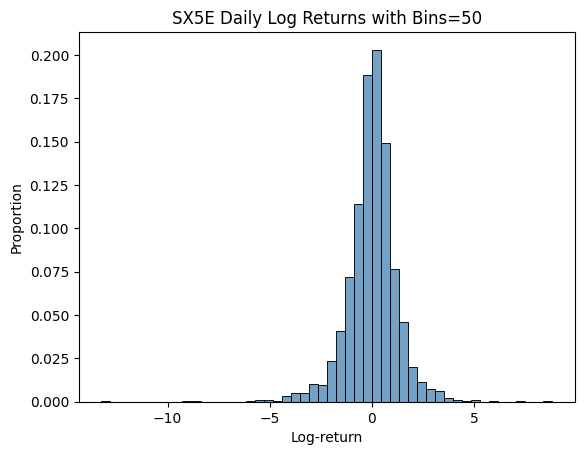

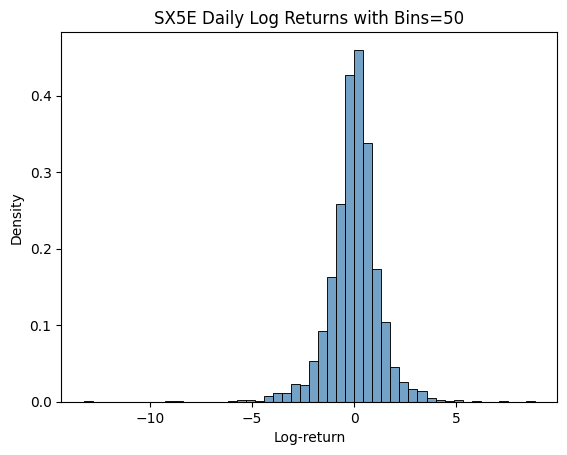

'\nFor the choice of bins, given the size of the dataset, a safe choice is sqrt(N) (square-root rule), \nwhere N = 2511is the size of the dataset. When comparing the histogram to the sample moments, we see that\nthe histogram does not reflect the asymetry of the dataset. However, after fitting a Kernel Density Estimator,\nwe can see clearly the longer tails on the lefthand side. \n'

In [7]:
# Draw also a histogram including a kernel density estimate 
# and a normal distribution (density) fitted to the log returns. What can you conclude

ax = sns.histplot(data=SX5E['logreturn'], bins=50, color='#4682b4', stat="proportion")
ax.set(xlabel='Log-return', ylabel='Proportion')
ax.set_title("SX5E Daily Log Returns with Bins=50")

plt.show()

# normalized histogram 
ax = sns.histplot(data=SX5E['logreturn'], bins=50, color='#4682b4', stat="density")
ax.set(xlabel='Log-return', ylabel='Density')
ax.set_title("SX5E Daily Log Returns with Bins=50")

plt.show()

'''
For the choice of bins, given the size of the dataset, a safe choice is sqrt(N) (square-root rule), 
where N = 2511is the size of the dataset. When comparing the histogram to the sample moments, we see that
the histogram does not reflect the asymetry of the dataset. However, after fitting a Kernel Density Estimator,
we can see clearly the longer tails on the lefthand side. 
'''

In [ ]:
'''
Skewness b is <0, which indicates asymetry, i.e. the left side exhibits a longer tail
we can see the longer lefthand tail better with the Kernel density estimator
Kurtosis k is >3 which indicates a leptokurtic distribution with an acute peak and heavy tails
'''

In [9]:
# compute additional metrics, e.g. skewness, kurtosis
from scipy.stats import kurtosis, skew

mu = SX5E['logreturn'].mean()
sigma = SX5E['logreturn'].std()
b = skew(SX5E['logreturn'][1:])
k = kurtosis(SX5E['logreturn'][1:])

print("***\nMean: {mu:.3f} \nStd. dev.: {sigma:.3f} \nSkewness: {b:.3f} \nKurtosis: {k:.3f}\n***".format(mu=mu, sigma=sigma, b=b, k=k))

***
Mean: 0.011 
Std. dev.: 1.238 
Skewness: -0.795 
Kurtosis: 10.264
***


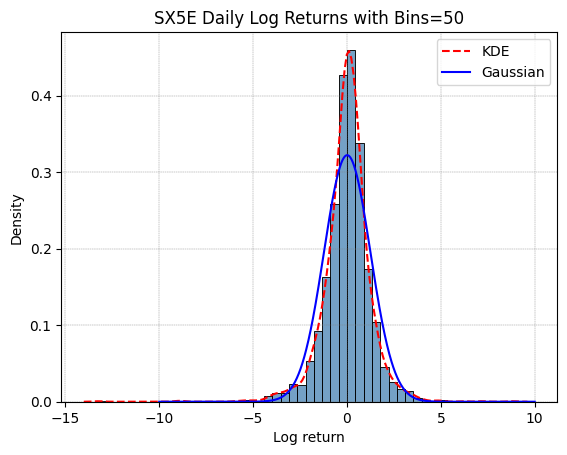

In [13]:
# import the "norm" function from the Scipy.stats library (normal pdf function)
from scipy.stats import norm

x = np.linspace(-10,10,1000)

# add the plot of N(\mu,\sigma) pdf on top of the seaborn histogram
sns_ax = sns.histplot(data=SX5E['logreturn'], bins=50, color="#4682b4", stat="density")
sns.kdeplot(data=SX5E['logreturn'], color="red", linestyle="--", label="KDE")
sns_ax.plot(x,norm.pdf(x,mu,sigma), color="blue", label="Gaussian")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("SX5E Daily Log Returns with Bins=50")
plt.legend()
plt.show()

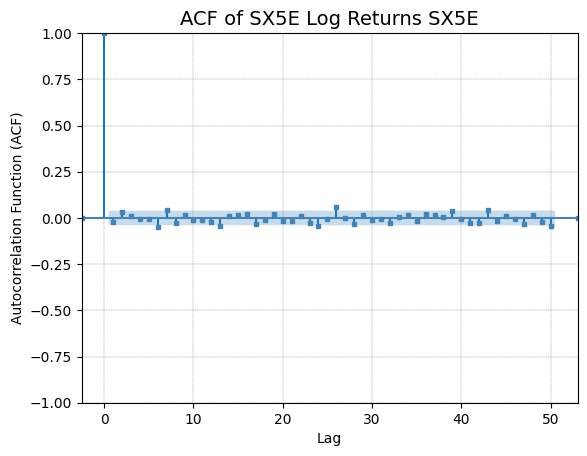

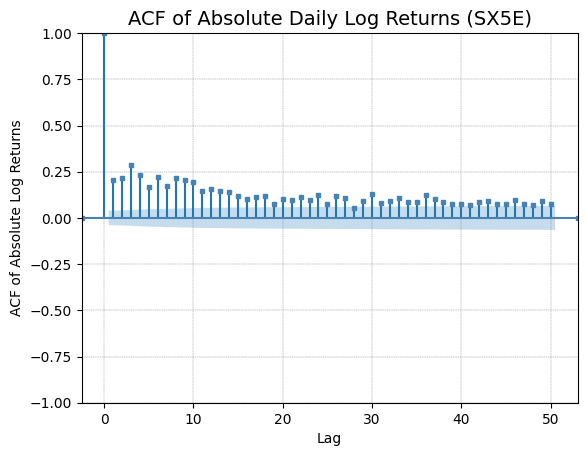

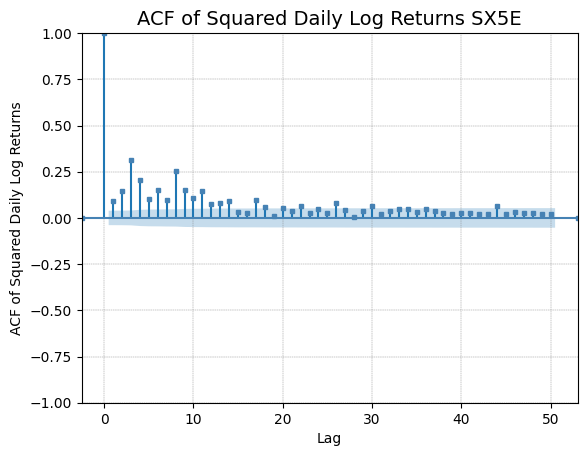

In [17]:
# part (ii) 
!pip install statsmodels
import statsmodels.api as sm

# ACF Daily Returns
sm.graphics.tsa.plot_acf(SX5E['logreturn'].dropna(), lags=50,color='#4682b4', 
                         marker='s',markersize=3)
plt.title("ACF of SX5E Log Returns SX5E", fontsize=14)
plt.xlabel("Lag", fontsize=10)
plt.ylabel("Autocorrelation Function (ACF)", fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

plt.show()

# ACF of abs(Daily Returns) 
sm.graphics.tsa.plot_acf(np.abs(SX5E['logreturn']).dropna(), lags=50, 
                         color='#4682b4', marker='s',markersize=3)
plt.title("ACF of Absolute Daily Log Returns (SX5E)", fontsize=14)
plt.xlabel("Lag", fontsize=10)
plt.ylabel("ACF of Absolute Log Returns", fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

plt.show()

# ACF of squared returns
squared_logreturns=SX5E['logreturn']**2
sm.graphics.tsa.plot_acf(squared_logreturns.dropna(), lags=50, 
                         color='#4682b4', marker='s',markersize=3)
plt.title("ACF of Squared Daily Log Returns SX5E", fontsize=14)
plt.xlabel("Lag", fontsize=10)
plt.ylabel("ACF of Squared Daily Log Returns", fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()


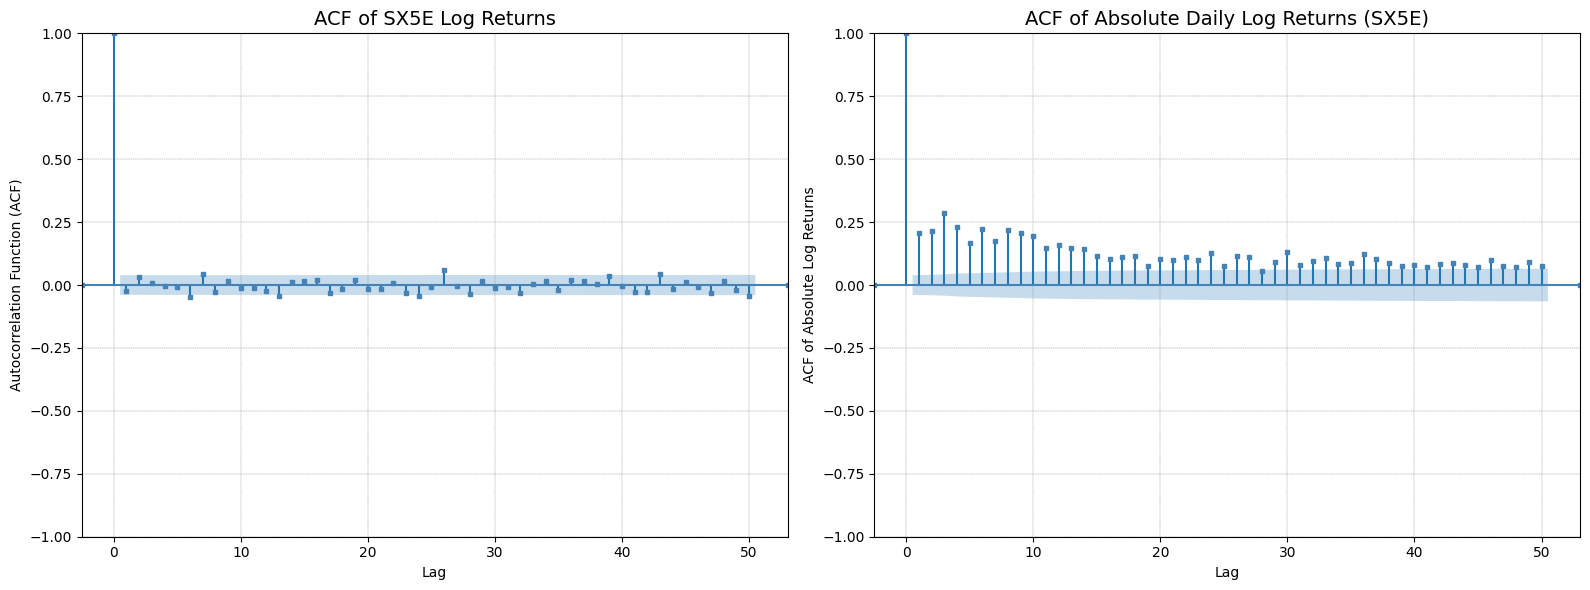

In [19]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: ACF of Daily Log Returns
sm.graphics.tsa.plot_acf(SX5E['logreturn'].dropna(), lags=50, color='#4682b4',
                         marker='s', markersize=3, ax=axes[0])
axes[0].set_title("ACF of SX5E Log Returns", fontsize=14)
axes[0].set_xlabel("Lag", fontsize=10)
axes[0].set_ylabel("Autocorrelation Function (ACF)", fontsize=10)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Subplot 2: ACF of Absolute Daily Log Returns
sm.graphics.tsa.plot_acf(np.abs(SX5E['logreturn']).dropna(), lags=50, 
                         color='#4682b4', marker='s', markersize=3, ax=axes[1])
axes[1].set_title("ACF of Absolute Daily Log Returns (SX5E)", fontsize=14)
axes[1].set_xlabel("Lag", fontsize=10)
axes[1].set_ylabel("ACF of Absolute Log Returns", fontsize=10)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [ ]:
'''
The ACF values for log returns are consistently small when k !=0, suggesting a lack of coffelation. 
This lack of dependence also means that forecasting daily returns based on historical observation could raise 
challenges.

Conversely, the ACF values for absolute returns are more conspicuous, suggesting volatility clustering--the
phenomenon for large/small price changes to be followed by large/small price changes. When k=50,
the ACF of the absolute returns has albeit decreased (suggesting less correlation over time), 
but this decretionn is less signifcant than the standard ACF values. 
We also see volatility persistence, i.e. the ACF of absolute daily returns decays slowly, as k increases
Again, we see that another effect of the volatility persistence is that the peak (volatility shock) at
approximately time 3 appears to affect the volatility in sequencial time steps.

Finally, the ACF of squared log returns also provides insight on the serial dependence of the volatility.
In particular, we see volatility clustering when k=3 and k=8. In contrast to the ACF of absolute returns, 
there is a significant decrease in ACF values as k increases.  
'''

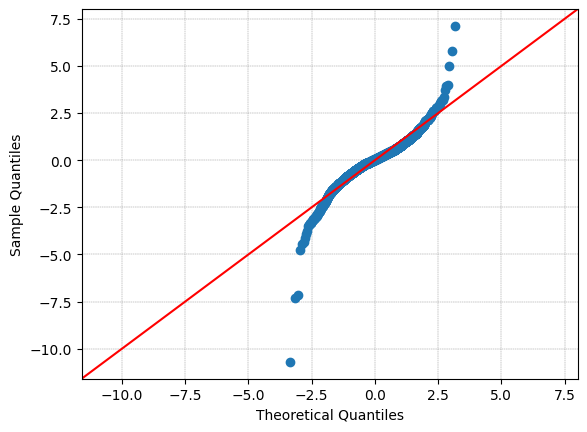

In [15]:
# QQ Plot
import statsmodels.api as sm

# remember to normalise the data against the mean and sd!!
z = (SX5E['logreturn'] - mu)/sigma
sm.qqplot(z, line='45')
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()


In [ ]:
'''
Lastly, we analyze the sample quantiles against the theoretical quantiles of a N(0,1) distribution. 
From the lack of fitting between the sample data and the theoretical values, this suggests that the data does 
not follow a normal distribution. This is also supported by the KDE estimate and kurtosis, which reports 
heavier tails and asymetry. 
'''

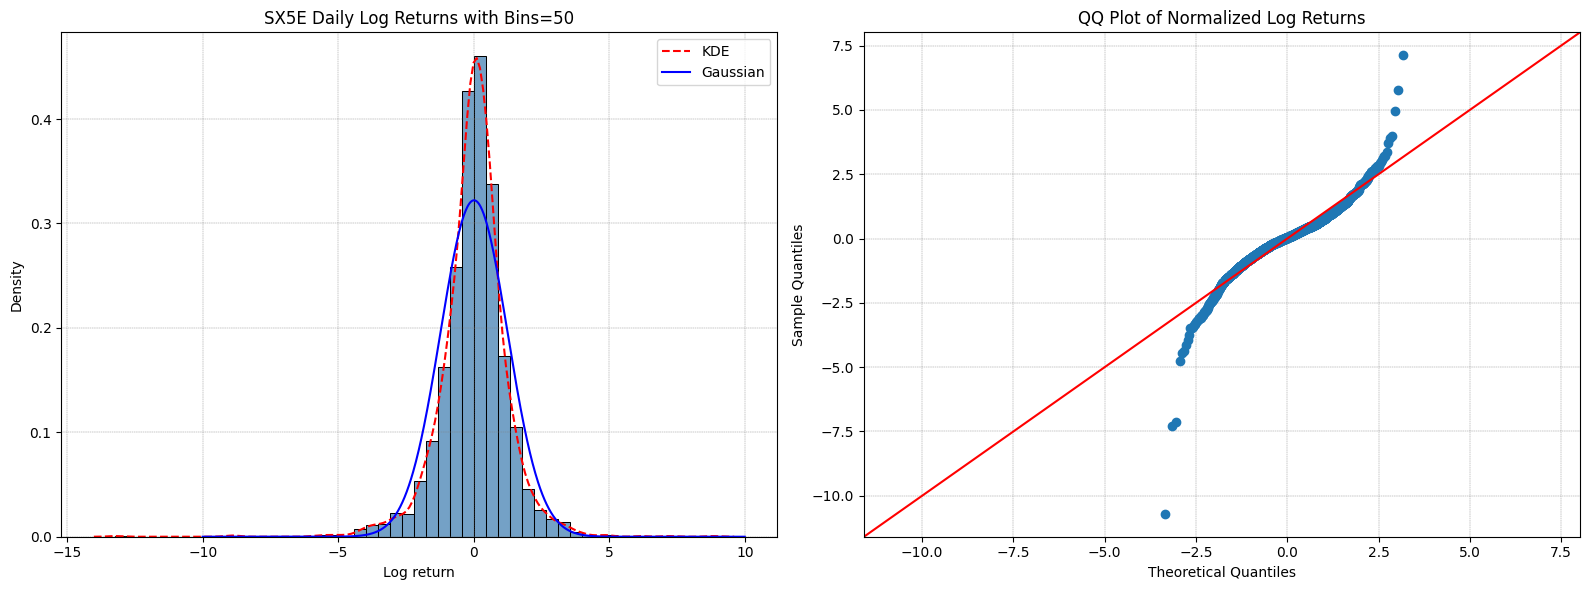

In [16]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Histogram with KDE and Gaussian curve
sns_ax = sns.histplot(data=SX5E['logreturn'], bins=50, color="#4682b4", stat="density", ax=axes[0])
sns.kdeplot(data=SX5E['logreturn'], color="red", linestyle="--", label="KDE", ax=axes[0])
axes[0].plot(x, norm.pdf(x, mu, sigma), color="blue", label="Gaussian")
axes[0].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
axes[0].set_xlabel("Log return")
axes[0].set_ylabel("Density")
axes[0].set_title("SX5E Daily Log Returns with Bins=50")
axes[0].legend()

# Subplot 2: QQ plot
sm.qqplot(z, line='45', ax=axes[1])
axes[1].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
axes[1].set_title("QQ Plot of Normalized Log Returns")

# Adjust layout and show
plt.tight_layout()
plt.show()

# Stylised facts and GARCH modelling

In [26]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from arch import arch_model
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.stats import t

In [27]:
# This part is about statistical analysis and modelling of the EURO STOXX 50 (symbol:SX5E) stock market index. The index measures the performance of the 50 largest
# and most liquid Eurozone stocks. The file QRM-2024-cw1-data-a.csv contains its daily values at market close from 30 October 2013 to 27 October 2023.
# Import data 
data = pd.read_csv("QRM-2024-cw1-data-a.csv", index_col=0)
data.index = pd.to_datetime(data.index)

/var/folders/1r/n0289fts6fzcc8k7qcw3p7s40000gn/T/ipykernel_35654/2198534766.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data.index = pd.to_datetime(data.index)


In [28]:
# Compute the daily log returns of the index
data["log_returns"] = 100 * np.log(data["Adj Close"]).diff()
data = data.dropna() # Drop the first row

#### Question 1 - Compute the mean, standard deviation, skewness, and kurtosis of the log returns. Draw also a histogram including a kernel density estimate and a normal distribution (density) fitted to the log returns.

Mean of the log returns: 0.011775216013590195
Standard deviation of the log returns: 1.239143121478602
Skewness of the log returns: -0.7959744140691218
Kurtosis of the log returns: 10.27807324061866


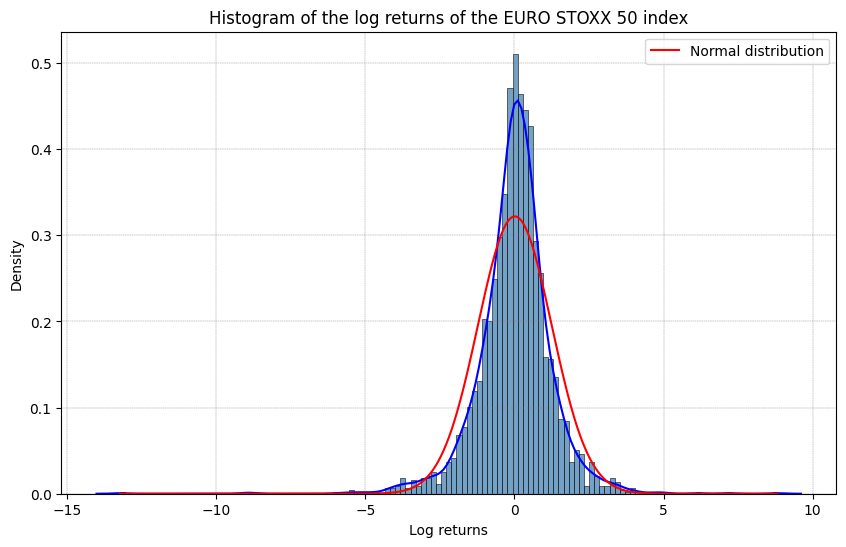

In [29]:
mean = data["log_returns"].mean()
std = data["log_returns"].std()
skewness = data["log_returns"].skew()
kurtosis = data["log_returns"].kurtosis()

print(f"Mean of the log returns: {mean}")
print(f"Standard deviation of the log returns: {std}")
print(f"Skewness of the log returns: {skewness}")
print(f"Kurtosis of the log returns: {kurtosis}")

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(data["log_returns"], stat="density", color="#4682B4")
sns.kdeplot(data["log_returns"], color="blue")
plt.title("Histogram of the log returns of the EURO STOXX 50 index")
plt.xlabel("Log returns")
plt.ylabel("Density")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Fit a normal distribution to the log returns

# Compute the mean and standard deviation of the normal distribution
mu, sigma = norm.fit(data["log_returns"])
x = np.linspace(data["log_returns"].min(), data["log_returns"].max(), 1000)
y = norm.pdf(x, mu, sigma)

# Plot the normal distribution
plt.plot(x, y, color="red", label="Normal distribution")
plt.legend()
plt.show()




#### Question 2 - Draw the empirical ACFs of the log returns, their absolute values, and their squares.


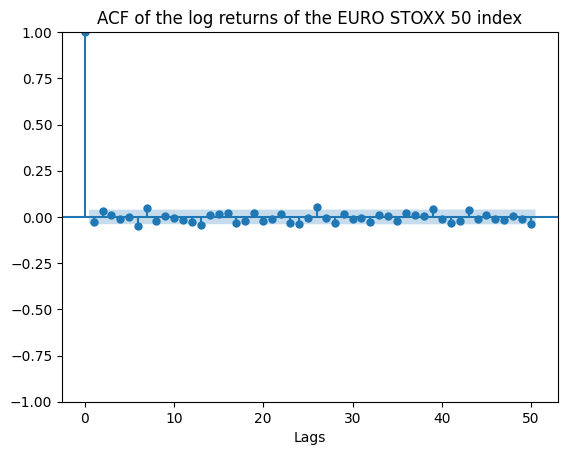

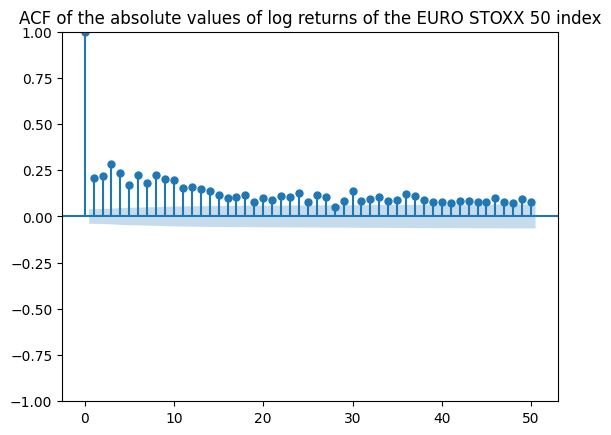

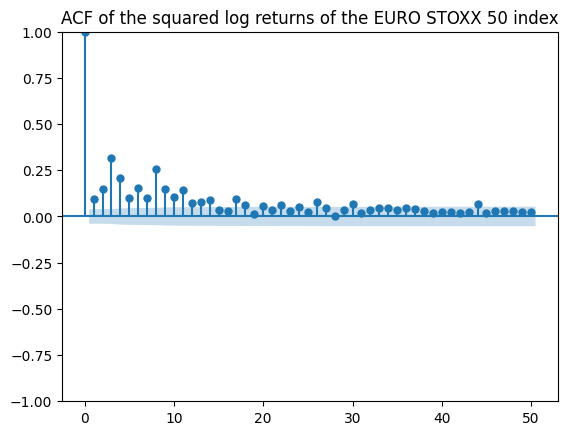

In [30]:
# Plot the ACF of the log returns
sm.graphics.tsa.plot_acf(data["log_returns"], lags=50, title="ACF of the log returns of the EURO STOXX 50 index")
plt.xlabel("Lags")
plt.show()

# Plot the ACF of the absolute values of log returns
sm.graphics.tsa.plot_acf(np.abs(data["log_returns"]), lags=50, title="ACF of the absolute values of log returns of the EURO STOXX 50 index")
plt.show()

# Plot the ACF of the squared log returns
sm.graphics.tsa.plot_acf(data["log_returns"]**2, lags=50, title="ACF of the squared log returns of the EURO STOXX 50 index")
plt.show()

#### Question 3

The specification of a GARCH(1,1) model is
\begin{align}
X_{t}=\mu +\sigma_t Z_t,\qquad \sigma_t^2=\alpha_0+\alpha_1 X_{t-1}^2 + \beta_1\sigma_{t-1}^2,
\end{align}
and, in this case, we assume $(Z_t)_t$ to be normally distributed strict white noises with common pdf $$f_Z(z)=\frac{1}{\sqrt{2\pi}}e^{-\frac{z^2}{2}}.$$

The log-likelihood function is in form of $$\ell(\alpha_0,\alpha_1,\beta_1;X)=\sum_{t=1}^T \left[-\log \sigma_t + \log f_Z\left(\frac{X_t}{\sigma_t}\right)\right]$$ with respect to the collection of GARCH parameters $(\alpha_0,\alpha_1,\beta_1)$ and our observed data $X=(X_t)_{t=0}^T$. 

In [31]:
# Fit a standard GARCH(1,1) model, with constant conditional mean and standard normal innovations, to the log return data. Report the model fitting results. 
# Plot the absolute returns and fitted volatilities

# Fit a GARCH(1,1) model with constant conditional mean and standard normal innovations
model = arch_model(data["log_returns"], mean="Constant", p=1, q=1, dist="Normal")
res = model.fit(update_freq=3)

print(res)

Iteration:      3,   Func. Count:     23,   Neg. LLF: 5150.730920026693
Iteration:      6,   Func. Count:     43,   Neg. LLF: 3738.9599901201914
Iteration:      9,   Func. Count:     58,   Neg. LLF: 3738.9201000406356
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3738.920093281495
            Iterations: 11
            Function evaluations: 67
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            log_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3738.92
Distribution:                  Normal   AIC:                           7485.84
Method:            Maximum Likelihood   BIC:                           7509.14
                                        No. Observations:                 2505
Date:               

In [32]:
# Print model summary
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:            log_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3738.92
Distribution:                  Normal   AIC:                           7485.84
Method:            Maximum Likelihood   BIC:                           7509.14
                                        No. Observations:                 2505
Date:                Wed, Nov 20 2024   Df Residuals:                     2504
Time:                        16:23:34   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0476  2.019e-02      2.360  1.830e-02 [8.

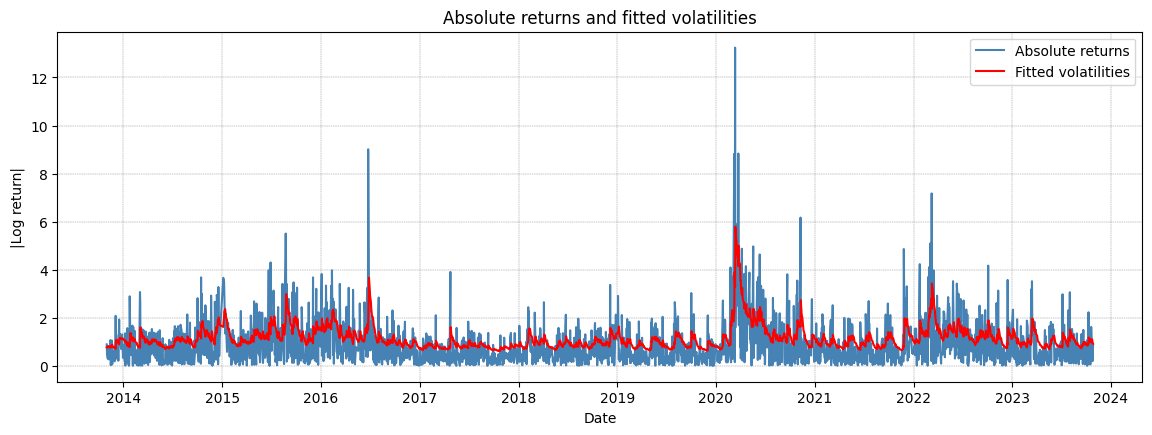

In [33]:
# Plot the absolute returns and fitted volatilities
# Use hexcode #4682B4 for the color of the absolute returns and #FF6347 for the color of the fitted volatilities
plt.figure(figsize=(14, 10))
plt.subplot(211)
plt.plot(data["log_returns"].abs(), label="Absolute returns", color="#4682B4")
plt.plot(res.conditional_volatility, label="Fitted volatilities", color="red")
plt.title("Absolute returns and fitted volatilities")
plt.xlabel("Date")
plt.ylabel("|Log return|")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()


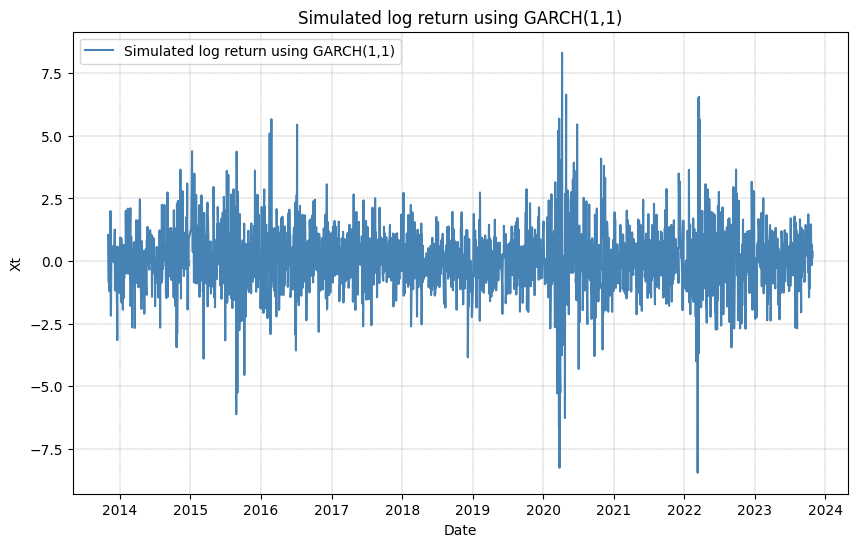

In [34]:
# Calculate Xt = mu + sigma_t * z_t, where z_t is a standard normal random variable
Xt = res.params["mu"] + res.conditional_volatility * np.random.normal(size=len(data))

# Plot the log returns and the simulated Xt
plt.figure(figsize=(10, 6))
plt.plot(Xt, label="Simulated log return using GARCH(1,1)", color="#4682B4")

plt.title("Simulated log return using GARCH(1,1)")
plt.xlabel("Date")
plt.ylabel("Xt")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

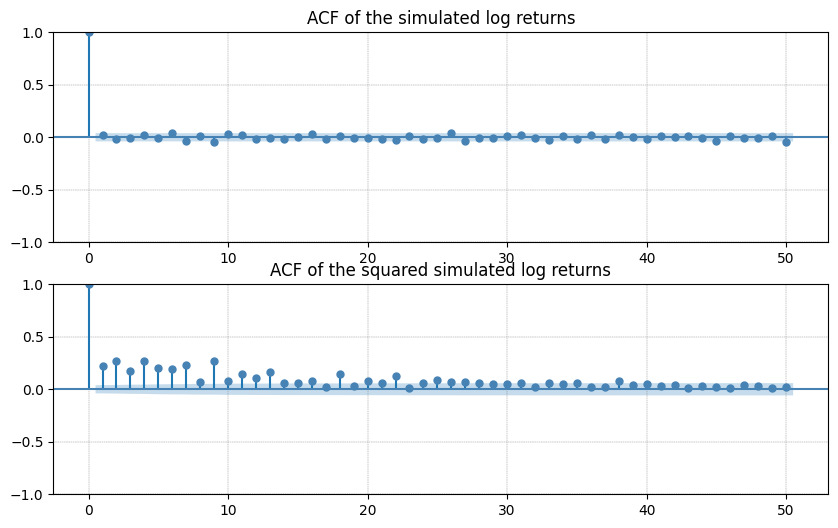

In [35]:
# ACFs of the simulated log returns and their squares
ax, fig = plt.subplots(2, 1, figsize=(10, 6))
sm.graphics.tsa.plot_acf(Xt, lags=50, title="ACF of the simulated log returns", ax=fig[0], color="#4682B4")
fig[0].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
sm.graphics.tsa.plot_acf(Xt**2, lags=50, title="ACF of the squared simulated log returns", ax=fig[1], color="#4682B4")
fig[1].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()



In [36]:
# mean, std, skewness, kurtosis
mean = Xt.mean()
std = Xt.std()
skewness = Xt.skew()
kurtosis = Xt.kurtosis()
print(f"Mean of the simulated log returns: {mean}")
print(f"Standard deviation of the simulated log returns: {std}")
print(f"Skewness of the simulated log returns: {skewness}")
print(f"Kurtosis of the simulated log returns: {kurtosis}")

Mean of the simulated log returns: 0.07129680235629253
Standard deviation of the simulated log returns: 1.2574525188331218
Skewness of the simulated log returns: 0.04292411818428977
Kurtosis of the simulated log returns: 5.1037608478459


#### Question 4

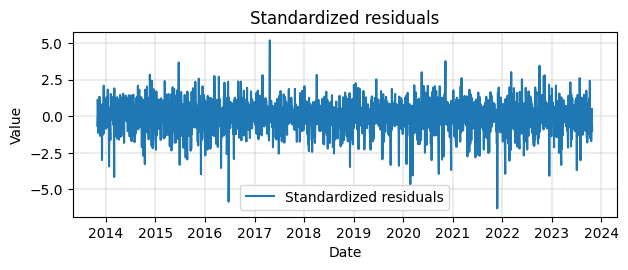

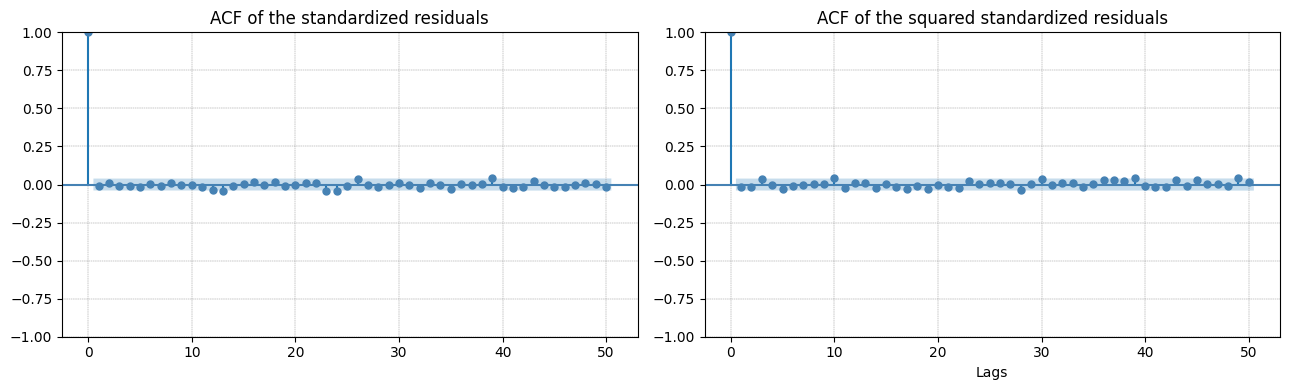

In [37]:
# Assess the goodness-of-fit of the GARCH(1,1) model by plotting the standardized residuals and their ACF.

# Plot the standardized residuals
plt.subplot(212)
plt.plot(res.resid / res.conditional_volatility, label="Standardized residuals")
plt.title("Standardized residuals")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()

# Plot the ACF of the standardized residuals and their squared values
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sm.graphics.tsa.plot_acf(res.resid / res.conditional_volatility, lags=50, ax=ax[0], title="ACF of the standardized residuals", color = "#4682b4")
sm.graphics.tsa.plot_acf((res.resid / res.conditional_volatility)**2, lags=50, ax=ax[1], title="ACF of the squared standardized residuals", color ="#4682b4")
plt.xlabel("Lags")
plt.tight_layout()
ax[0].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
ax[1].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()


/Users/bluee/Library/Python/3.9/lib/python/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


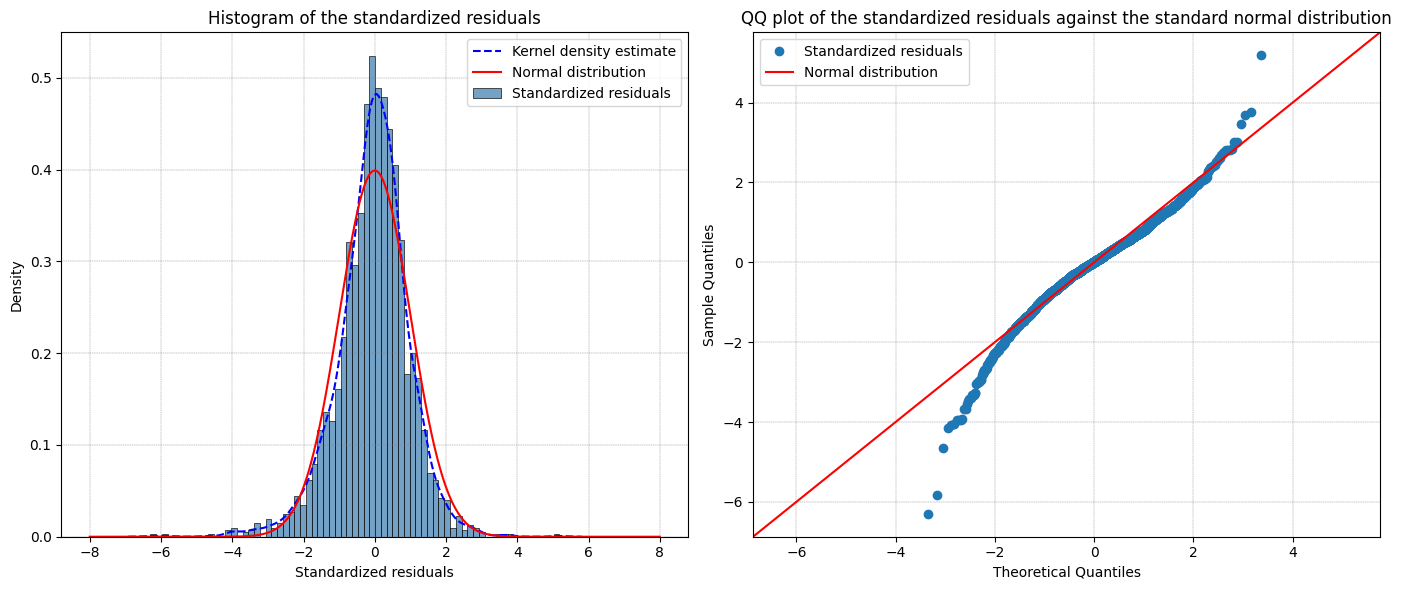

In [38]:
# Histogram of the standardized residuals, its kernel density estimate, and the standard normal density plotted side by side with QQ plot of the standardized residuals against the standard normal distribution. we take normal 0, 1
# Histogram of the standardized residuals
plt.figure(figsize=(14, 6))

plt.subplot(121)
sns.histplot(res.resid / res.conditional_volatility, stat="density", color="#4682b4", label="Standardized residuals", legend=True)
sns.kdeplot(res.resid / res.conditional_volatility, color="blue", linestyle="--",label="Kernel density estimate", legend=True)
plt.title("Histogram of the standardized residuals")
plt.xlabel("Standardized residuals")
plt.ylabel("Density")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# add the normal 0, 1 density
x = np.linspace(-8, 8, 1000)
y = norm.pdf(x, 0, 1)
plt.plot(x, y, color="red", label="Normal distribution")
plt.legend()

# QQ plot of the standardized residuals against the standard normal distribution
plt.subplot(122)
sm.qqplot(res.resid / res.conditional_volatility, line="45", ax=plt.gca(), color ="#4682b4")
plt.title("QQ plot of the standardized residuals against the standard normal distribution")
plt.legend(["Standardized residuals", "Normal distribution", "Kernel density estimate"])
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.tight_layout()
plt.show()


#### Question 5

The ARMA(1,1)-GARCH(1,1) model
\begin{align}
X_{t}&=\mu_t+\sigma_t Z_t,\\
\mu_t&=\mu+\phi_1(X_{t-1}-\mu)+\theta_1 (X_{t-1}-\mu_{t-1}),\\
\sigma_t^2&=\alpha_0+\alpha_1 (X_{t-1} - \mu_{t-1})^2 + \beta_1\sigma_{t-1}^2,
\end{align}
where $(Z_t)_t$ follows a normalised Student-t distribution with degree of freedom $\nu$.

The likelihood function is $$\ell(\alpha_0,\alpha_1,\beta_1, \mu,\phi_1,\theta_1, \nu;X)=\sum_{t=1}^T \left[-\log \sigma_t + \log f_Z\left(\frac{X_t-\mu_t}{\sigma_t}\right)\right]$$


In [39]:
# Fit an ARMA(1,1)–GARCH(1,1) model with Student t-distributed innovations
def arma11_garch11_t_loglikelihood(alpha0, alpha1, beta1, arma_mu, phi1, theta1, nu, x):

    # store time series of sigma_t^2 and mu_t
    var = np.zeros_like(x)
    mu = np.zeros_like(x)

    # set up proxies for sigma_0^2 and \mu_0
    var[0] = np.var(x, ddof=1) # sample variance
    mu[0] = np.mean(x) # sample mean

    # iterate over the ARMA(1,1)-GARCH(1,1) dynamics
    for i in range(1, len(x)):
        mu[i] = arma_mu + phi1 * (x.iloc[i-1] - arma_mu) + theta1 * (x.iloc[i-1] - mu[i-1])
        var[i] = alpha0 + alpha1 * (x.iloc[i-1] - mu[i-1])**2 + beta1 * var[i-1]

    return np.sum(-0.5*np.log(var[1:]) + np.log(t.pdf((x.iloc[1:]-mu[1:])/np.sqrt(var[1:]), nu, 0, np.sqrt((nu-2)/nu))))

In [40]:
x = data["log_returns"]
objfun_armagarch_t = lambda y : -1 * arma11_garch11_t_loglikelihood(y[0], y[1], y[2], y[3], y[4], y[5], y[6], x)
constraint = lambda y :  1 - y[1] - y[2]

y0 = [1, 0.1, 0.1, 0, 0, 0, 10]
print("Initial objective function value: " + str(objfun_armagarch_t(y0)))

bnds = ((0,np.inf), (0,1), (0,1), (-np.inf, np.inf), (-np.inf, np.inf), (-np.inf, np.inf), (2.01, np.inf))

con = {'type': 'ineq', 'fun': constraint}

sol = minimize(objfun_armagarch_t,y0,method='SLSQP',bounds=bnds,constraints=con, options={'disp': True}, hess='3-point')

print("Estimate of alpha0: " + str(sol.x[0]))
print("Estimate of alpha1: " + str(sol.x[1]))
print("Estimate of beta1: " + str(sol.x[2]))
print("Estimate of mu: " + str(sol.x[3]))
print("Estimate of phi1: " + str(sol.x[4]))
print("Estimate of theta1: " + str(sol.x[5]))
print("Estimate of nu: " + str(sol.x[6]))

Initial objective function value: 3828.5397544425814


/var/folders/1r/n0289fts6fzcc8k7qcw3p7s40000gn/T/ipykernel_35654/1356221751.py:12: RuntimeWarning: Method SLSQP does not use Hessian information (hess).
  sol = minimize(objfun_armagarch_t,y0,method='SLSQP',bounds=bnds,constraints=con, options={'disp': True}, hess='3-point')
/var/folders/1r/n0289fts6fzcc8k7qcw3p7s40000gn/T/ipykernel_35654/472990610.py:15: RuntimeWarning: overflow encountered in scalar power
  var[i] = alpha0 + alpha1 * (x.iloc[i-1] - mu[i-1])**2 + beta1 * var[i-1]
/var/folders/1r/n0289fts6fzcc8k7qcw3p7s40000gn/T/ipykernel_35654/472990610.py:14: RuntimeWarning: overflow encountered in scalar multiply
  mu[i] = arma_mu + phi1 * (x.iloc[i-1] - arma_mu) + theta1 * (x.iloc[i-1] - mu[i-1])
/var/folders/1r/n0289fts6fzcc8k7qcw3p7s40000gn/T/ipykernel_35654/472990610.py:15: RuntimeWarning: invalid value encountered in scalar multiply
  var[i] = alpha0 + alpha1 * (x.iloc[i-1] - mu[i-1])**2 + beta1 * var[i-1]
/var/folders/1r/n0289fts6fzcc8k7qcw3p7s40000gn/T/ipykernel_35654/4729906

Optimization terminated successfully    (Exit mode 0)
            Current function value: 3635.0922425801496
            Iterations: 35
            Function evaluations: 311
            Gradient evaluations: 34
Estimate of alpha0: 0.047456242008100086
Estimate of alpha1: 0.14768174504878487
Estimate of beta1: 0.8335484349115174
Estimate of mu: 0.06985516437644283
Estimate of phi1: 0.911435166815261
Estimate of theta1: -0.9335259832504165
Estimate of nu: 4.727062738456344


In [41]:
# parameter estimates
alpha0 = sol.x[0]
alpha1 = sol.x[1]
beta1 = sol.x[2]
mu = sol.x[3]
phi1 = sol.x[4]
theta1 = sol.x[5]
nu = sol.x[6]

In [42]:
# Calculate AIC / BIC 
n = len(x)
k = 7
aic = 2 * sol.fun + 2 * k
bic = 2 * sol.fun + k * np.log(n)

print("AIC: " + str(aic))
print("BIC: " + str(bic))

AIC: 7284.184485160299
BIC: 7324.966793254932


In [43]:
# Calculate the time series of the conditional mean and volatility
mu_t = [np.mean(x)]
for i in range(len(x)):
    mu_t.append(mu + phi1 * (x.iloc[i-1] - mu) + theta1 * (x.iloc[i-1] - mu_t[i-1]))
mu_t = mu_t[1:]
sigma_t = [np.std(x)]
for i in range(1, len(x)):
    sigma_t.append(alpha0 + alpha1 * (x.iloc[i-1] - mu_t[i-1])**2 + beta1 * sigma_t[i-1])



In [ ]:
# Calculate Xt = mu_t + sigma_t * z_t, where z_t is a standard normal random variable
Xt = mu_t + np.sqrt(sigma_t) * np.random.normal(size=len(x)) 

In [46]:
# Calculate mean, std, skewness, kurtosis
# convert to pandas series
Xt = pd.Series(Xt)
mean = Xt.mean()
std = Xt.std()
skewness = Xt.skew()
kurtosis = Xt.kurtosis()
print(f"Mean of the simulated log returns: {mean}")
print(f"Standard deviation of the simulated log returns: {std}")
print(f"Skewness of the simulated log returns: {skewness}")
print(f"Kurtosis of the simulated log returns: {kurtosis}")


Mean of the simulated log returns: 0.07499972069304896
Standard deviation of the simulated log returns: 1.2639974776610008
Skewness of the simulated log returns: -0.13704676602078486
Kurtosis of the simulated log returns: 4.318858377922297


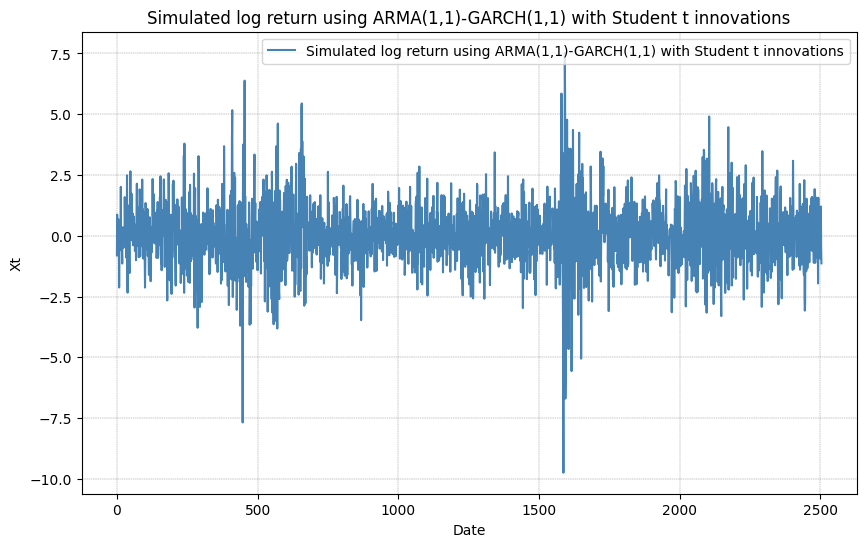

In [47]:
# Plot simulated Xt

plt.figure(figsize=(10, 6))
plt.plot(Xt, label="Simulated log return using ARMA(1,1)-GARCH(1,1) with Student t innovations", color="#4682B4")
plt.title("Simulated log return using ARMA(1,1)-GARCH(1,1) with Student t innovations")
plt.xlabel("Date")
plt.ylabel("Xt")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()

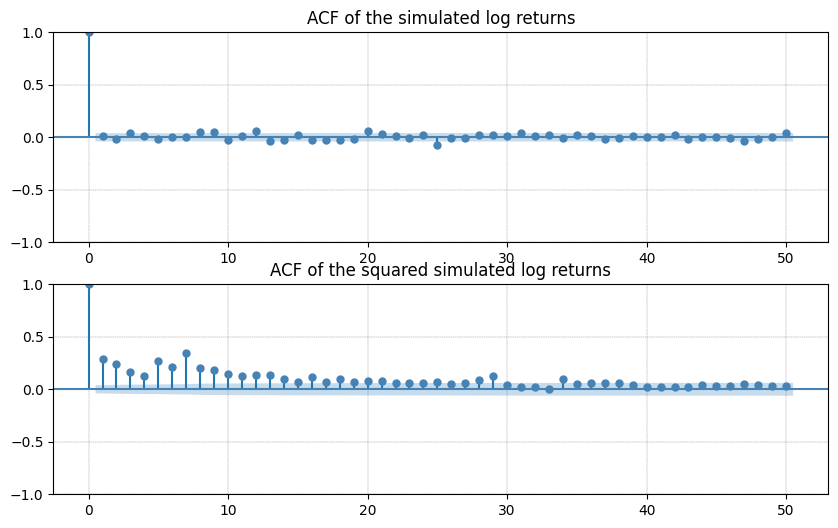

In [48]:
# ACF of Xt and Xt^2
ax, fig = plt.subplots(2, 1, figsize=(10, 6))
sm.graphics.tsa.plot_acf(Xt, lags=50, title="ACF of the simulated log returns", ax=fig[0], color="#4682B4")
fig[0].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
sm.graphics.tsa.plot_acf(Xt**2, lags=50, title="ACF of the squared simulated log returns", ax=fig[1], color="#4682B4")
fig[1].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()


In [323]:
sigma_t_series = pd.Series(sigma_t, index=x.index)

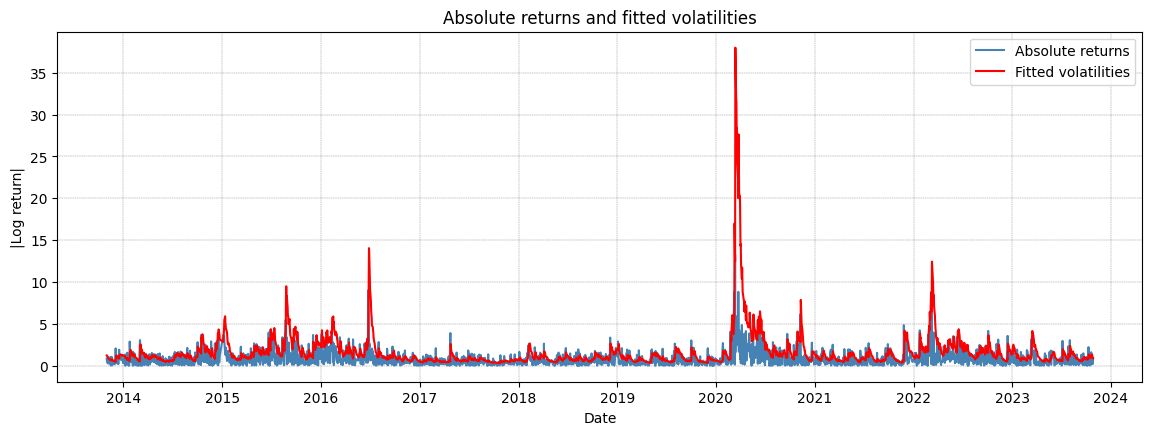

In [324]:
# Plot the absolute returns and fitted volatilities
plt.figure(figsize=(14, 10))
plt.subplot(211)
plt.plot(x.abs(), label="Absolute returns", color="#4682b4")
plt.plot(sigma_t_series, label="Fitted volatilities", color="red")
plt.title("Absolute returns and fitted volatilities")
plt.xlabel("Date")
plt.ylabel("|Log return|")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()


In [325]:
# Plot the qq plot of the standardized residuals of the ARMA(1,1)–GARCH(1,1) model with Student t-distributed innovations
# Calculate the residuals

epsilon_t = x - mu_t
Z_t = epsilon_t / sigma_t

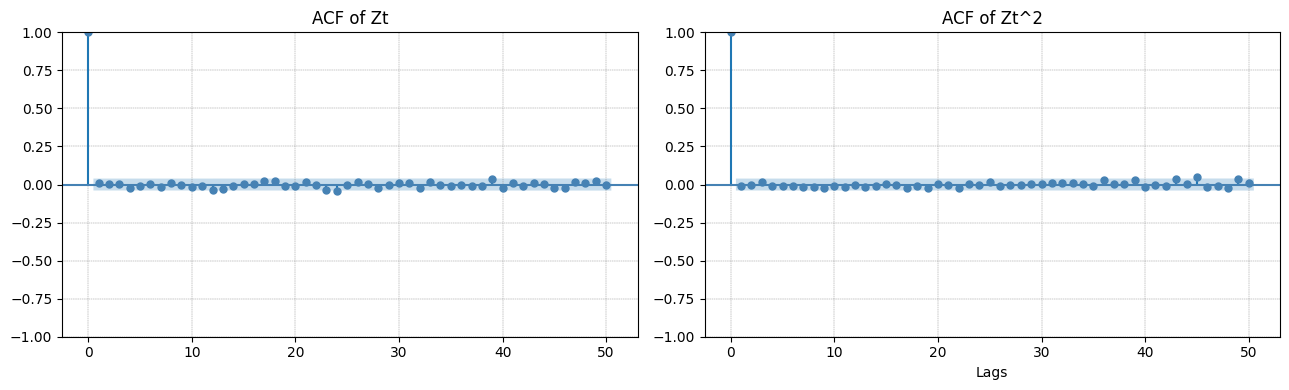

In [326]:
# plot the acfs of Zt and Zt^2
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sm.graphics.tsa.plot_acf(Z_t, lags=50, ax=ax[0], title="ACF of Zt", color = "#4682b4")
sm.graphics.tsa.plot_acf(Z_t**2, lags=50, ax=ax[1], title="ACF of Zt^2", color = "#4682b4")
ax[0].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
ax[1].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.xlabel("Lags")
plt.tight_layout()
plt.show()


/Users/bluee/Library/Python/3.9/lib/python/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


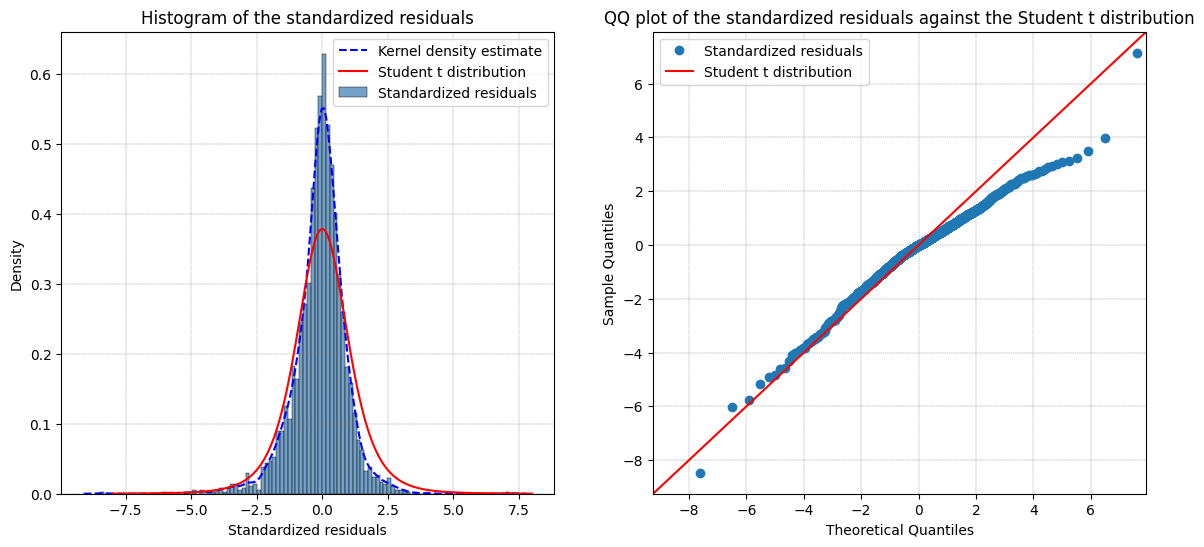

<Figure size 640x480 with 0 Axes>

In [327]:

# Histogram and QQ plot of the standardized residuals against Student t-distributed innovations

plt.figure(figsize=(14, 6))

plt.subplot(121)
sns.histplot(Z_t, stat="density", color="#4682b4", label="Standardized residuals", legend=True)
sns.kdeplot(Z_t, color="blue", linestyle="--",label="Kernel density estimate", legend=True)
plt.title("Histogram of the standardized residuals")
plt.xlabel("Standardized residuals")
plt.ylabel("Density")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# add the student t density with estimated nu
u = np.linspace(-8, 8, 1000)
v = t.pdf(u, nu, 0, 1)
plt.plot(u, v, color="red", label="Student t distribution")
plt.legend()

plt.subplot(122)
sm.qqplot(Z_t, t, distargs=(sol.x[6],), line="45", ax=plt.gca(), color = "#4682b4")
plt.title("QQ plot of the standardized residuals against the Student t distribution")
plt.legend(["Standardized residuals", "Student t distribution", "Kernel density estimate"])
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

plt.show()
plt.tight_layout()

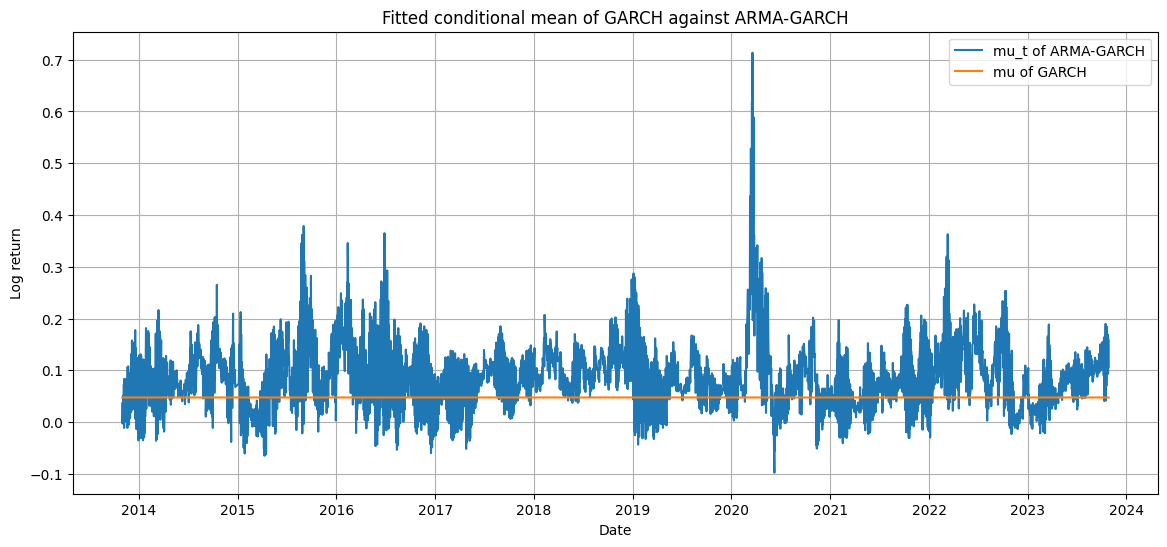

<Figure size 640x480 with 0 Axes>

In [328]:
# plot of the return series and the fitted conditional mean
mu_series = pd.Series(mu_t, index=x.index) 
plt.figure(figsize=(14, 6))
#plt.plot(x, label="Return series", color="skyblue")
plt.plot(mu_series, label="mu_t of ARMA-GARCH")
plt.plot(pd.Series([res.params.mu for i in range(len(x))], index=x.index), label="mu of GARCH")
plt.title("Fitted conditional mean of GARCH against ARMA-GARCH")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.legend()
plt.grid(True)
plt.show()
plt.tight_layout()

In [329]:
# Fitting of garch(1,1) with student innovation 
model = arch_model(data["log_returns"], mean="Constant", p=1, q=1, dist="t")
res = model.fit(update_freq=3)
print(res)


Iteration:      3,   Func. Count:     26,   Neg. LLF: 6823.932449740945
Iteration:      6,   Func. Count:     50,   Neg. LLF: 3642.453091152984
Iteration:      9,   Func. Count:     70,   Neg. LLF: 3639.899229250238
Iteration:     12,   Func. Count:     88,   Neg. LLF: 3639.8954625192855
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3639.8954625192855
            Iterations: 13
            Function evaluations: 93
            Gradient evaluations: 13
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                  log_returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3639.90
Distribution:      Standardized Student's t   AIC:                           7289.79
Method:                  Maximum Likelihood   BIC:                          

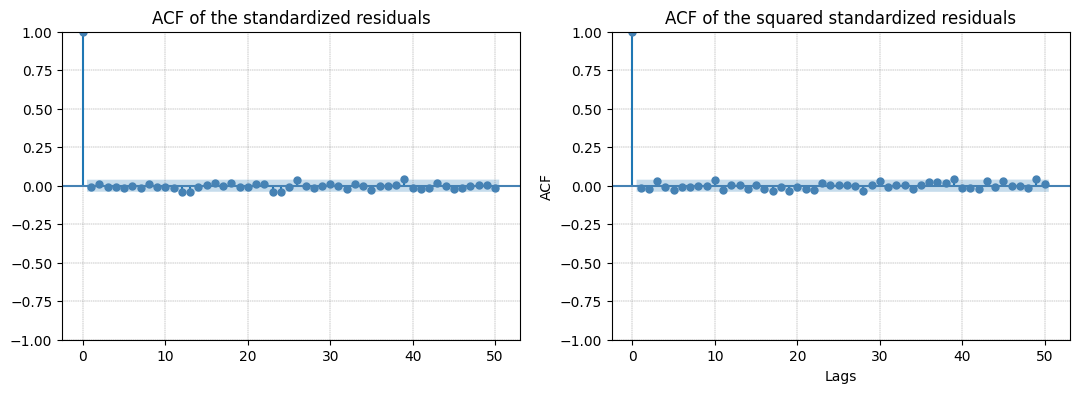

In [330]:
# ACFs of the standardized residuals and their squared values

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sm.graphics.tsa.plot_acf(res.resid / res.conditional_volatility, lags=50, title="ACF of the standardized residuals",  color ="#4682b4", ax = ax[0])
plt.title("ACF of the standardized residuals")
plt.xlabel("Lags")
plt.ylabel("ACF")
plt.grid(True)

sm.graphics.tsa.plot_acf((res.resid / res.conditional_volatility)**2, lags=50, title="ACF of the squared standardized residuals",  color ="#4682b4", ax=ax[1])
plt.title("ACF of the squared standardized residuals")
plt.xlabel("Lags")
plt.ylabel("ACF")
ax[0].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
ax[1].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

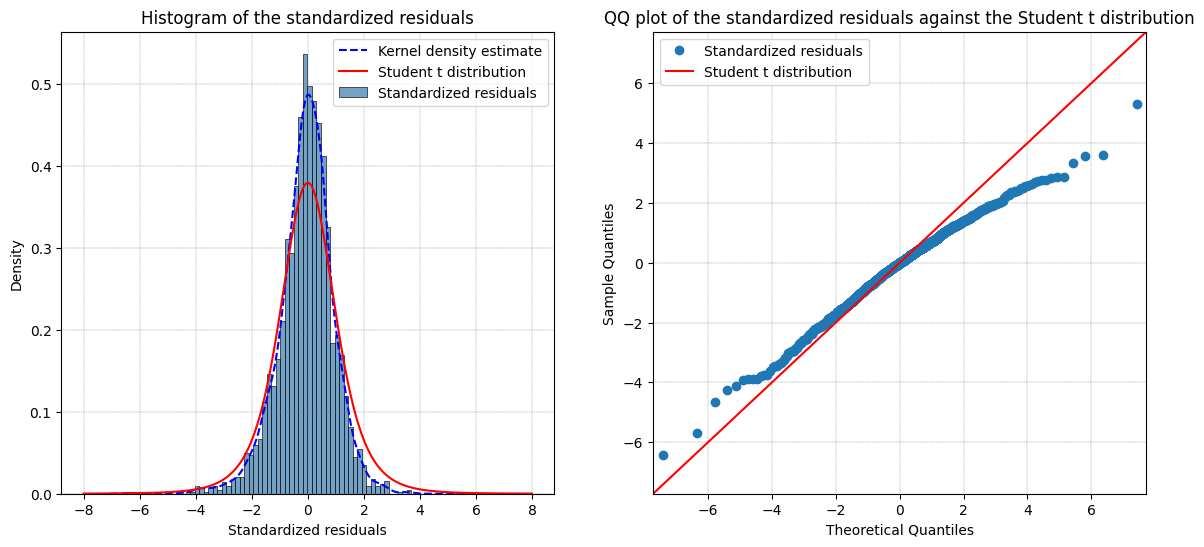

<Figure size 640x480 with 0 Axes>

In [332]:
# Histogram and QQ plot of the standardized residuals against Student t-distributed innovations
plt.figure(figsize=(14, 6))

plt.subplot(121)
sns.histplot(res.resid / res.conditional_volatility, stat="density", color="#4682b4", label="Standardized residuals", legend=True)
sns.kdeplot(res.resid / res.conditional_volatility, color="blue", linestyle="--",label="Kernel density estimate", legend=True)
plt.title("Histogram of the standardized residuals")
plt.xlabel("Standardized residuals")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# add the student t density with estimated nu
u = np.linspace(-8, 8, 1000)
v = t.pdf(u, res.params["nu"], 0, 1)
plt.plot(u, v, color="red", label="Student t distribution")
plt.legend()

plt.subplot(122)
sm.qqplot(res.resid / res.conditional_volatility, t, distargs=(res.params["nu"],), line="45", ax=plt.gca())
plt.title("QQ plot of the standardized residuals against the Student t distribution")
plt.legend(["Standardized residuals", "Student t distribution", "Kernel density estimate"])
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()
plt.tight_layout()

# Part B Risk Measures

Import of DOG data and compute log returns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.ticker as tick

# Import data
DOG = pd.read_csv("QRM-2024-cw1-data-b.csv")

# Check Data
print(DOG.head())


# Reformat data and have sensible date times etc
DOG.Date = pd.to_datetime(DOG.Date, dayfirst = True)

DOG = DOG.set_index('Date')

print(DOG.head())



         Date   Adj Close
0  30/10/2013  105.445374
1  31/10/2013  105.823196
2  01/11/2013  105.407578
3  04/11/2013  105.256462
4  05/11/2013  105.407578
             Adj Close
Date                  
2013-10-30  105.445374
2013-10-31  105.823196
2013-11-01  105.407578
2013-11-04  105.256462
2013-11-05  105.407578


In [2]:

# Compute log returns expressed as percentages
logDOG = -np.log(DOG/DOG.shift(1)) * 100

logDOG = pd.DataFrame.dropna(logDOG)

print(logDOG.head())
print(type(logDOG))

            Adj Close
Date                 
2013-10-31  -0.357670
2013-11-01   0.393521
2013-11-04   0.143466
2013-11-05  -0.143466
2013-11-06   0.900081
<class 'pandas.core.frame.DataFrame'>


Thomas note - this is correct, looking at the average log returns, they are positive more than not in the graph below. Since this is the opposite of the DOW, the losses should look like the DOW, which on average had positive returns over the period.

### i) Historical Simulation

We will write a function that takes in empirical data, and returns the alpha quantile

In [3]:
def historical_VaR(loss_observations, alpha):
    """
    Input: 
    loss_observations (pd.DataFrame): the dataframe containing the losses.
    alpha: the quantile level.
    Output:
    the VaR of the given losses.
    """
    ### Takes loss_observations, a numpy array of log losses, and calculates the quantile that represents the value at risk based on the empirical distribution of the observations
    # ### In practice, this means we just order the observations based on their extremity (small to large), and take the smallest value in the alpha percentile
    # observation_array = loss_observations.values
    # n = np.size(observation_array)
    # observation_array = np.sort(observation_array)
    
    # # we take the ceiling, see markdown below for explanation
    # observation = int(np.ceil(n * alpha))

    # return observation_array[observation-1][0]

    ############## Today I learnt that the quantile function exists in numpy, so I'll just use that

    return np.quantile(loss_observations.values, alpha)




$ F_{empirical}(x) = \sum_{i=1}^{n} 1_{L_i \leq x}
\newline$
And
$\newline VaR_{\alpha}(L) := inf(l \in \mathbb{R} : \mathbb{P}(L \leq l ) \geq {\alpha})
\newline$  
Therefore if $\frac{m}{N} < \alpha \leq \frac{m+1}{N}\newline$

Then $\alpha$ must correspond to the observed $m+1th$ value of $L_{i}$. Without loss of generality they are sorted, and this is $L_{m+1} \newline$
Therefore to identify $m+1$ we simply round up the value of ${\alpha}{N}$



We now write a function that will compute the Expected Shortfall (although the below statements are only true under the assumption of a continuous CDF)

$\newline ES_{\alpha}(L) = \mathbb{E}[L | L \geq VaR_{\alpha}(L)] = \frac{ \mathbb{E}[L{\mathbb{1}_{L \geq VaR_{\alpha}(L)}}]}{1-\alpha}$

This is effectively just computing the conditional expectation. Empirically this can be done by just taking the mean of values above the value at risk threshold, which are just the most extreme $N(1-\alpha)$ observations. (More specifically this is $N - ceil({\alpha}N))$, as noted above.

In [4]:
def historical_ES(loss_observations, alpha):
    # ### Takes loss_observations, a numpy array of log losses, and calculates the expected shortfall for those losses

    # # First we order the losses, and calculate the size of the array
    # n = np.size(loss_observations)
    # loss_observations = np.sort(loss_observations)

    # # For the observation that breaches, again take the ceiling
    # observation = int(np.ceil(n * alpha))

    # # The total number of breaches is therefore 
    # breaches = n - observation + 1

    # # With the total of the breaches being
    # total_of_breaches = loss_observations[observation - 1:].sum()

    # # And we just return the conditional average
    # return total_of_breaches/breaches

    # Again, today I learnt that my code could be much simpler..., see below:

    quantile = np.quantile(loss_observations.values, alpha)
    return loss_observations.values[loss_observations.values >= quantile].mean()



Now as a sanity check, we check both functions are working correctly on the header data of logDOG

In [5]:
print("Historical VaR with header data and alpha = 0.5")
print("After hand calculating, should return the 3rd largest value, 0.1435")
print(historical_VaR(logDOG.head(), 0.5))

print("Expected Shortfall with header data and alpha = 0.5")
print("After hand calculating, should return the value (0.1435 + 0.3935 + 0.9001)/3 = 0.479")
print(historical_ES(logDOG.head()['Adj Close'], 0.5))

Historical VaR with header data and alpha = 0.5
After hand calculating, should return the 3rd largest value, 0.1435
0.1434663703588546
Expected Shortfall with header data and alpha = 0.5
After hand calculating, should return the value (0.1435 + 0.3935 + 0.9001)/3 = 0.479
0.4790228612378395


They work! Isn't that great. We will return to the plotting once we have written the implementation for the filtered historical simulation models.

### ii) Filtered Historical Simulation (FHS) with exponentially-weighted moving average (EWMA)

We will compute the next volatility:
$\newline \hat{\sigma}_{t+1}^2 = \alpha (X_t - \hat{\mu}_t)^2 + (1 - \alpha) \hat{\sigma}_t^2$

Specifically we'll do so by first computing the variance over the sample as $ \hat{\sigma}_t^2$

As noted in the lecture notes we will take $\alpha$ as 0.06, and we will take $X_t$ as $ L_t $

In the lecture notes, it is stated that the conditional mean $\hat{\mu}_t $ is often just taken to be zero. I will take this assumption, but first check it is valid by computing it over the observation set, though I don't expect it to be significantly different from 0.

To verify this assumption, I have done a few calculations below over some rolling averages in the data set:

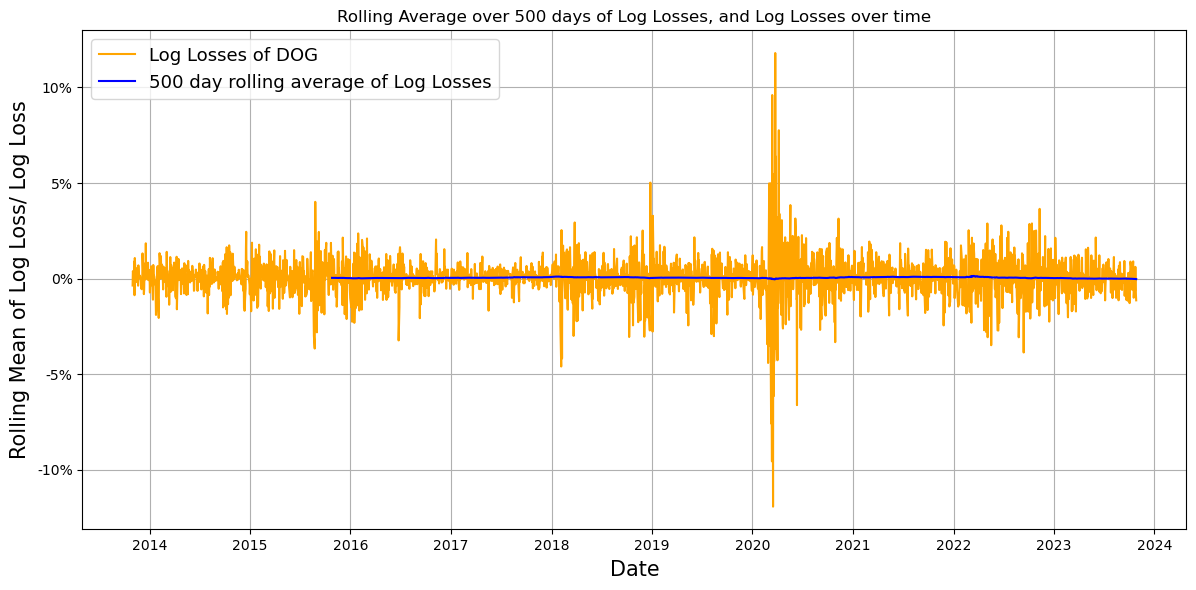

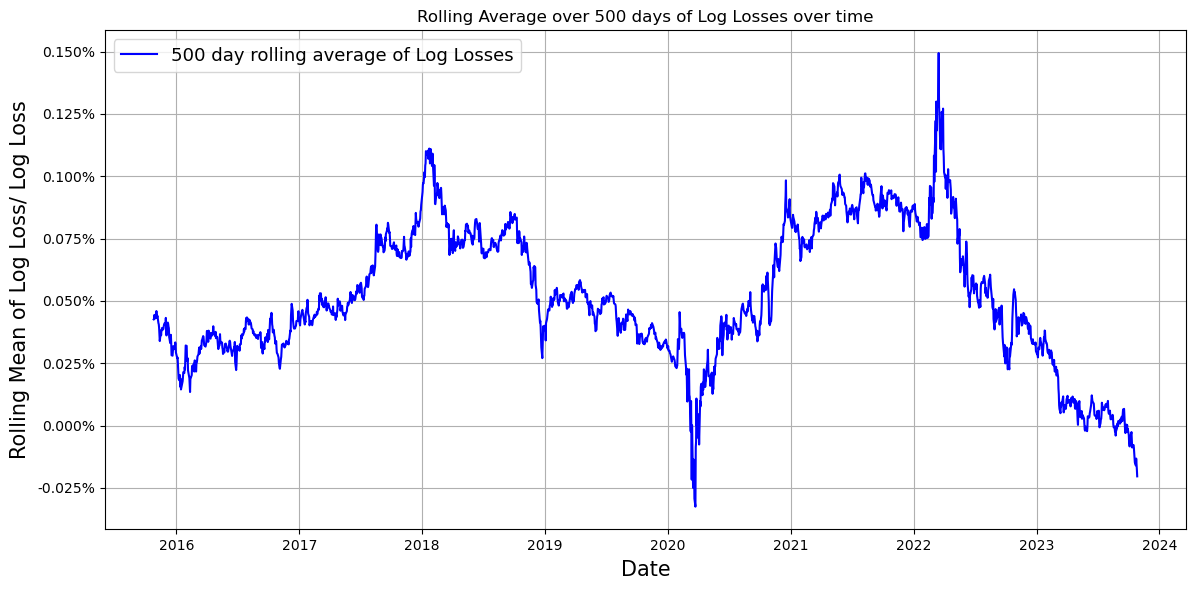

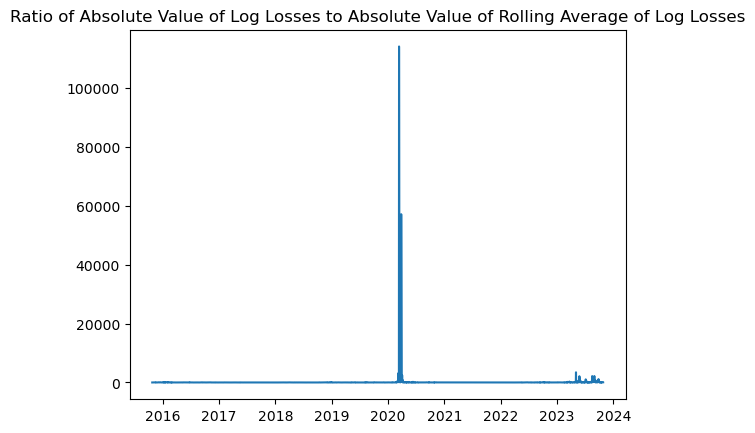

In [6]:
import matplotlib.pyplot as plt
import functools
# Plot the log returns

fig = plt.figure(figsize = (12, 6))
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Rolling Mean of Log Loss/ Log Loss", fontsize = 15, labelpad= 5)



plt.plot(logDOG, color = 'orange', label = 'Log Losses of DOG')
# Plot the rolling average
plt.plot(logDOG.rolling(500).mean().dropna(), color = 'blue', label = '500 day rolling average of Log Losses')
plt.title("Rolling Average over 500 days of Log Losses, and Log Losses over time")

plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))



plt.savefig('plot_5_rolling_mean.png')
plt.show()


###############################################################################

# Plotting just the rolling average of log returns
fig = plt.figure(figsize = (12, 6))
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Rolling Mean of Log Loss/ Log Loss", fontsize = 15, labelpad= 5)



#plt.plot(logDOG, color = 'orange', label = 'Log Losses of DOG')
# Plot the rolling average
plt.plot(logDOG.rolling(500).mean().dropna(), color = 'blue', label = '500 day rolling average of Log Losses')
plt.title("Rolling Average over 500 days of Log Losses over time")

plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.3f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))



plt.savefig('plot_6_rolling_mean_only.png')
plt.show()


plt.title("Ratio of Absolute Value of Log Losses to Absolute Value of Rolling Average of Log Losses")
plt.plot((logDOG/logDOG.rolling(500).mean()).dropna().abs())
plt.show()

From the graphs above, it's clear that the rolling average is usually negligible compared to the log returns for that day, except for a large spike around March 2020, which coincides with the start of the COVID-19 Pandemic. To capture this possibility which may indicate increased volatility and therefore unmodelled risk, I will include the actual conditional mean (on the rolling obsevation period) in my implementation.

As instructed we will take $ \hat{\mu}_t = 0 $ giving:

$\newline \hat{\sigma}_{t+1}^2 = \alpha X_t^2 + (1 - \alpha) \hat{\sigma}_t^2$

We will then compute our estimates as follows $\newline \hat{VaR}_{\alpha}(L_{t+1}) = \hat{\mu}_{t+1} + \hat{\sigma}_{t+1}q_{\alpha}({\hat{F}_Z}) 
\newline \hat{ES}_{\alpha}(L_{t+1}) = \hat{\mu}_{t+1} + \hat{\sigma}_{t+1}ES_{\alpha}({\hat{F}_Z})$

Where $\hat{F}_Z$ is the empirical distribution of $\hat{Z}_0, \hat{Z}_1, ..., \hat{Z}_t$ with $\hat{Z}_i = \frac{\hat{\epsilon}_i}{\hat{\sigma}_i}$, where the residuals are $ \hat{\epsilon}_i = L_i - \hat{{\mu}}_i = L_i $, where the EWMA forecast again assuming that $\hat{\mu}_i = 0 \ \forall \ i$ is a good approximation.

Where the residuals are $ \hat{\epsilon}_t = L_t - \hat{{\mu}}_t $, where the EWMA forecast can then be written as:

$\newline \hat{\sigma}_{t+1}^2 = {\alpha}_0 + {\alpha}_1 \hat{\epsilon}_t^2 + {\beta}_1 \hat{\sigma}_t^2 $

Whcih is an integrated $ GARCH(1,1) $ process.

To compute an initial value for $ \hat{\sigma}_0 $ we will take the standard deviation of the first 500 values. 

We note that there is some capacity for this choice to have an influence on the results for future values of the calculated variances. An alternative could be taking $ \hat{\sigma}_0 = 0$ for example, or taking $ \hat{\sigma}_0 $ to be the standard deviation over the whole time series (although this is not possible to do in reality as we cannot know the future values), or taking it as some outrageous figure, such as a $ \hat{\sigma}_0 = 1,000$

In [7]:
import datetime

var_0 = np.empty(len(logDOG))
var_average = np.empty(len(logDOG))
var_silly = np.empty(len(logDOG))

var_0[0] = 0
var_average[0] = logDOG["Adj Close"].var()
var_silly[0] = 1000000


var = np.empty(len(logDOG))
var[0] = logDOG["Adj Close"][0:500].var()



print("The value of the initial value is below:")

print(var[0])

print("Which is very small! So taking a value of 0 would not have made much difference in the long run.")

ewma_alpha = 0.06

# The below is the direct formula in EWMA
for i in range(0, len(logDOG)-1):
    var[i+1] = ewma_alpha * logDOG["Adj Close"][i]**2 + (1 - ewma_alpha) * var[i]
    var_0[i+1] = ewma_alpha * logDOG["Adj Close"][i]**2 + (1 - ewma_alpha) * var_0[i]
    var_average[i+1] = ewma_alpha * logDOG["Adj Close"][i]**2 + (1 - ewma_alpha) * var_average[i]
    var_silly[i+1] = ewma_alpha * logDOG["Adj Close"][i]**2 + (1 - ewma_alpha) * var_silly[i]

var = pd.DataFrame(var)
var = var.set_index(logDOG.index)

var_0 = pd.DataFrame(var_0)
var_0 = var_0.set_index(logDOG.index)

var_average = pd.DataFrame(var_average)
var_average = var_average.set_index(logDOG.index)

var_silly = pd.DataFrame(var_silly)
var_silly = var_silly.set_index(logDOG.index)





The value of the initial value is below:
0.6455835862687189
Which is very small! So taking a value of 0 would not have made much difference in the long run.


C:\Users\rapto\AppData\Local\Temp\ipykernel_33212\1926752985.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  var[i+1] = ewma_alpha * logDOG["Adj Close"][i]**2 + (1 - ewma_alpha) * var[i]
C:\Users\rapto\AppData\Local\Temp\ipykernel_33212\1926752985.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  var_0[i+1] = ewma_alpha * logDOG["Adj Close"][i]**2 + (1 - ewma_alpha) * var_0[i]
C:\Users\rapto\AppData\Local\Temp\ipykernel_33212\1926752985.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFram

We will now compare visually the various time series to evaluate the sensitivity to initial conditions. We note that at each iteration in the EWMA process the next implied variance $\hat{\sigma}_{t+1} $ only has a 0.94 weighting on the value of the previous variance value $\hat{\sigma}_t $, and so we expect the variance's dependence on the initial value to exponentially decay over time as the EWMA process becomes dominated by the actual observation values.

<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
C:\Users\rapto\AppData\Local\Temp\ipykernel_33212\3602869786.py:14: SyntaxWarning: invalid escape sequence '\h'
  plt.legend(fontsize = 13, title = "Starting Value of $\hat{\sigma}_0$")


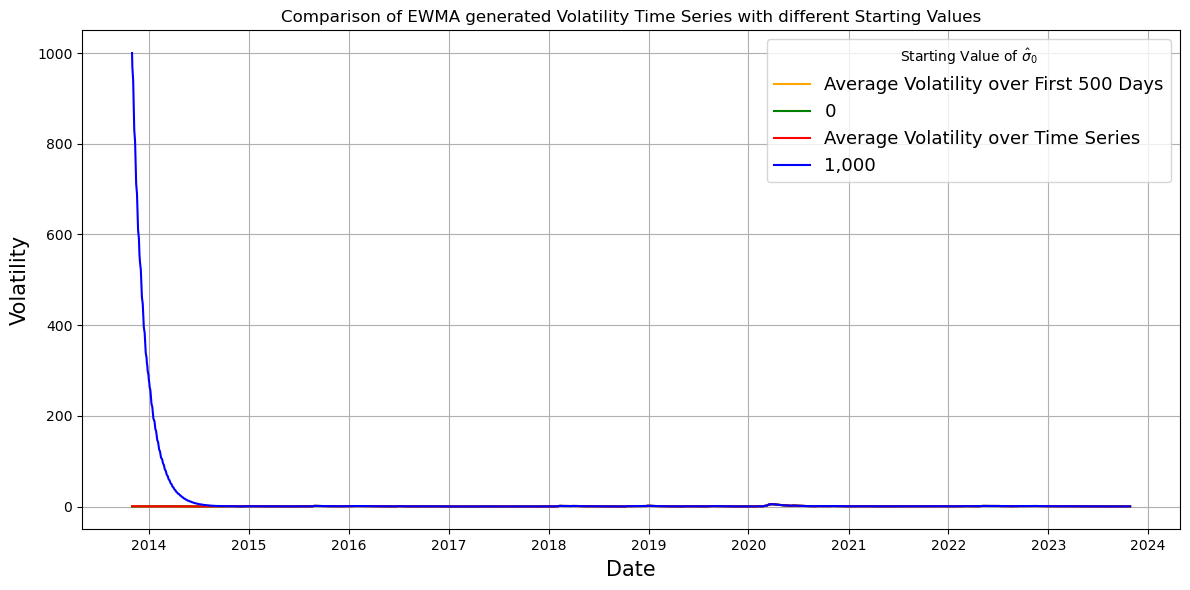

In [8]:
# Plot 7

fig = plt.figure(figsize = (12, 6))
plt.title("Comparison of EWMA generated Volatility Time Series with different Starting Values")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Volatility", fontsize = 15, labelpad= 5)
plt.plot(np.sqrt(var), color = 'orange', label = "Average Volatility over First 500 Days")
plt.plot(np.sqrt(var_0), color = 'green', label = "0")
plt.plot(np.sqrt(var_average), color = 'red', label = "Average Volatility over Time Series")
plt.plot(np.sqrt(var_silly), color = 'blue', label = "1,000")

plt.legend(fontsize = 13, title = "Starting Value of $\hat{\sigma}_0$")
plt.tight_layout()

#def y_fmt(x, y):
#    return f"{x:.0f}%"


#plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

#plt.ylim(bottom = 0)

plt.savefig('plot_7_volatility_time_series')

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
C:\Users\rapto\AppData\Local\Temp\ipykernel_33212\2722514390.py:14: SyntaxWarning: invalid escape sequence '\h'
  plt.legend(fontsize = 13, title = "Starting Value of $\hat{\sigma}_0$")


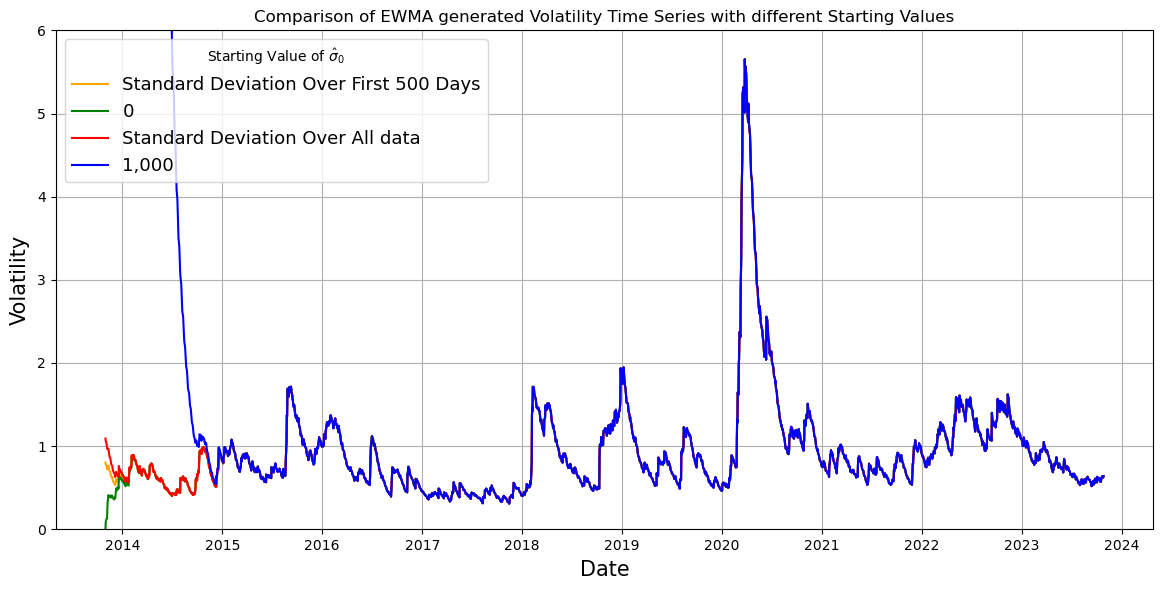

In [9]:
# Plot 8

fig = plt.figure(figsize = (12, 6))
plt.title("Comparison of EWMA generated Volatility Time Series with different Starting Values")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Volatility", fontsize = 15, labelpad= 5)
plt.plot(np.sqrt(var), color = 'orange', label = "Standard Deviation Over First 500 Days")
plt.plot(np.sqrt(var_0), color = 'green', label = "0")
plt.plot(np.sqrt(var_average), color = 'red', label = "Standard Deviation Over All data")
plt.plot(np.sqrt(var_silly), color = 'blue', label = "1,000")

plt.legend(fontsize = 13, title = "Starting Value of $\hat{\sigma}_0$")
plt.tight_layout()

#def y_fmt(x, y):
#    return f"{x:.0f}%"


#plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0, top = 6)
plt.savefig('plot_8_volatility_time_series_zoomed')

plt.show()

We'll pre compute the empirical observations to save on compute

In [10]:
# Note we take the square root of the variances, since they are variances, and not the standard deviations
empirical_observations = pd.DataFrame(logDOG.values/np.sqrt(var.values)).set_index(logDOG.index)

print("Empirical Observations")
print(empirical_observations)

Empirical Observations
                   0
Date                
2013-10-31 -0.445150
2013-11-01  0.501994
2013-11-04  0.187263
2013-11-05 -0.192931
2013-11-06  1.246966
...              ...
2023-10-23 -0.968713
2023-10-24  0.970508
2023-10-25 -0.556280
2023-10-26 -1.364859
2023-10-27 -1.772087

[2515 rows x 1 columns]


In [11]:

def ewma_vaR(loss_observations, alpha, var, empirical_observations):
    ### Calculates the value at risk under the ewma process, with numpy array of loss_observations, alpha, and variances
    
    # Take the variance that was calculated for the next item in the data frame
    var_t_1 = var.iloc[var.index.get_loc(loss_observations.index[-1]) + 1]

    #print("Predicted calculated variance")
    #print(var_t_1)

    mu_0 = 0 # loss_observations.mean()

    # calculate the normalised empirical observations

    #print("Calculated variances")
    #print(var.loc[loss_observations.index])


    # Only want the empirical observations relevant to the losses
    empirical_observations = empirical_observations.loc[loss_observations.index].values
    #print("Empirical Observations")
    #print(empirical_observations)
    

    # We then want the alpha quartile of the empirical observations, similar to as calculated before as with the historical VaR

    quantile =  np.quantile(empirical_observations, alpha)

    return (mu_0 + np.sqrt(var_t_1) * quantile)[0]

    



In [12]:
def ewma_ES(loss_observations, alpha, var, empirical_observations):
    ### Calculates the value at risk under the ewma process, with numpy array of loss_observations, alpha, and variances
    
    # Take the variance that was calculated for the next item in the data frame
    
    var_t_1 = var.iloc[var.index.get_loc(loss_observations.index[-1]) + 1]

    #print("Predicted calculated variance")
    #print(var_t_1)

    mu_0 = 0 # loss_observations.mean()

    # calculate the normalised empirical observations

    #print("Calculated variances")
    #print(var.loc[loss_observations.index])


    # Only want the empirical observations relevant to the losses
    empirical_observations = empirical_observations.loc[loss_observations.index].values
    #print("Empirical Observations")
    #print(empirical_observations)
    

    # We then want the expected shortfall of the empirical observations, similar to as calculated before with the historical ES

    quantile = np.quantile(empirical_observations, alpha)

    empirical_ES = empirical_observations[empirical_observations >= quantile].mean()

    return mu_0 + np.sqrt(var_t_1[0]) * empirical_ES

    

In [13]:
print(logDOG.head())

print("EWMA VaR Test:")
print(ewma_vaR(logDOG.head(), 0.5, var, empirical_observations))

print("EWMA Expected Shortfall Test:")
print(ewma_ES(logDOG.head(), 0.5, var, empirical_observations))


            Adj Close
Date                 
2013-10-31  -0.357670
2013-11-01   0.393521
2013-11-04   0.143466
2013-11-05  -0.143466
2013-11-06   0.900081
EWMA VaR Test:
0.13740136373796114
EWMA Expected Shortfall Test:
0.4735582662842891


We will now compute the expected shortfalls, and value at risk under Historical Simulation, EWMA Filtered Historical Simulation, at each confidence level

First Under Historical Simulation:

In [14]:
def HS_VaR_Forecast(data, rolling_window, alpha):

    VaR = np.empty(np.size(data)- rolling_window)

    for i in range(0, len(VaR)):
        VaR[i] = historical_VaR(data.iloc[i: i+rolling_window], alpha)


    VaR = pd.DataFrame(VaR).set_index(data.iloc[rolling_window:].index)

    return VaR



In [15]:
def HS_ES_Forecast(data, rolling_window, alpha):

    expected_shortfalls = np.empty(np.size(data)- rolling_window)

    for i in range(0, len(expected_shortfalls)):
        expected_shortfalls[i] = historical_ES(data.iloc[i: i+rolling_window], alpha)


    expected_shortfalls = pd.DataFrame(expected_shortfalls).set_index(data.iloc[rolling_window:].index)


    return expected_shortfalls

We then plot the graphs

In [16]:


hs_ES_test_forecasts_99 = HS_ES_Forecast(logDOG, 500, 0.99)
hs_VaR_test_forecasts_99 = HS_VaR_Forecast(logDOG, 500, 0.99)
hs_VaR_breaches_99 = logDOG.loc[hs_VaR_test_forecasts_99.index].values > hs_VaR_test_forecasts_99.values


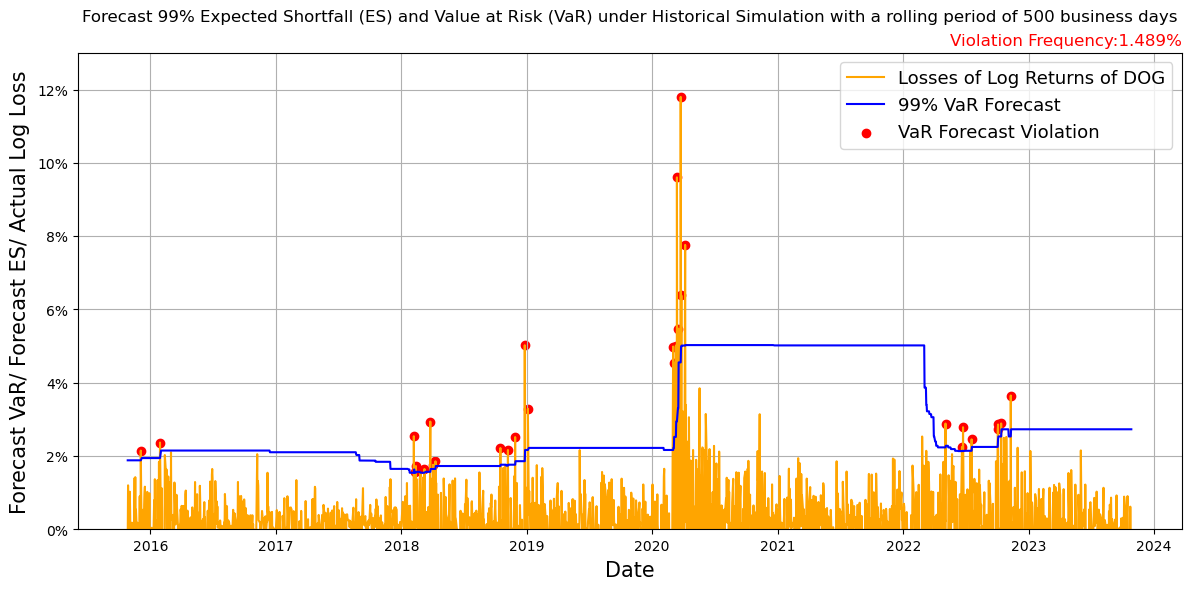

In [52]:
# Plot 3


fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 99% Expected Shortfall (ES) and Value at Risk (VaR) under Historical Simulation with a rolling period of 500 business days", y = 1.05)
plt.title("Violation Frequency:" + str(round(30/2015*100, 3)) +"%", loc = 'right', color = 'red')
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(hs_VaR_test_forecasts_99, label = "99% VaR Forecast", color = 'blue')
plt.scatter(logDOG.loc[hs_VaR_test_forecasts_99.index][hs_VaR_breaches_99].index, logDOG.loc[hs_VaR_test_forecasts_99.index][hs_VaR_breaches_99].values, color = 'red', label = 'VaR Forecast Violation')
#plt.plot(hs_ES_test_forecasts_99, color = 'red', label = "99% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)
plt.savefig('plot_3_hs_var_99_breaches')
plt.show()



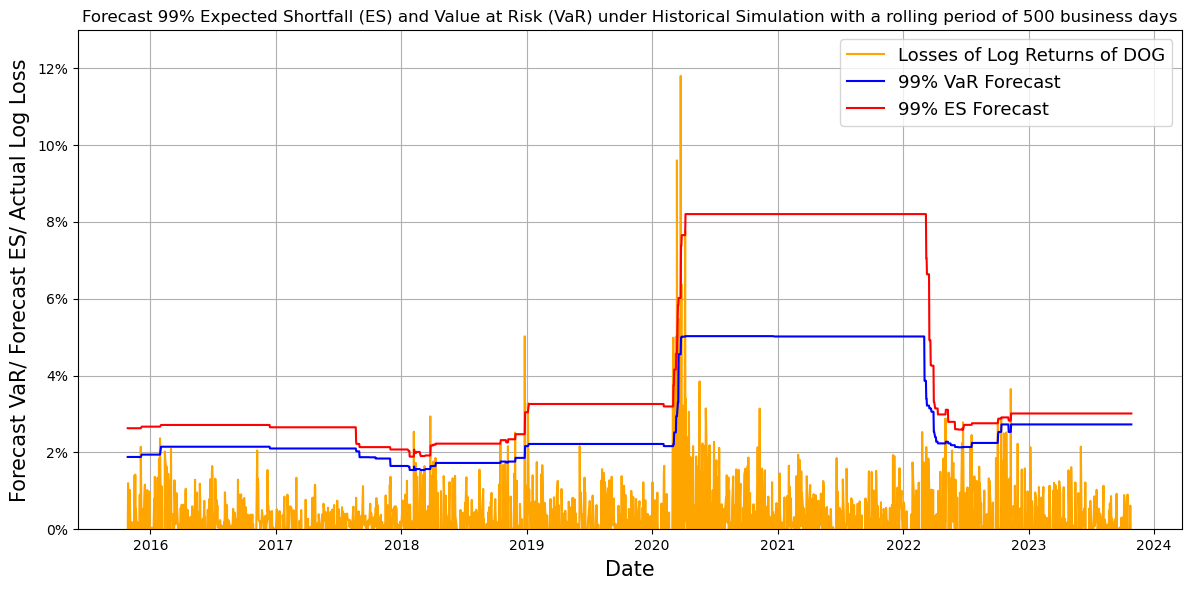

In [18]:
# Plot 4


fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 99% Expected Shortfall (ES) and Value at Risk (VaR) under Historical Simulation with a rolling period of 500 business days")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(hs_VaR_test_forecasts_99, label = "99% VaR Forecast", color = 'blue')
#plt.scatter(logDOG.loc[hs_VaR_test_forecasts_99.index][hs_VaR_breaches_99].index, logDOG.loc[hs_VaR_test_forecasts_99.index][hs_VaR_breaches_99].values, color = 'red', alpha = 0.5, label = 'VaR Forecast Violation')
plt.plot(hs_ES_test_forecasts_99, color = 'red', label = "99% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)
plt.savefig('plot_4_hs_99')
plt.show()



In [19]:
hs_ES_test_forecasts_95 = HS_ES_Forecast(logDOG, 500, 0.95)
hs_VaR_test_forecasts_95 = HS_VaR_Forecast(logDOG, 500, 0.95)

print(len(hs_ES_test_forecasts_95))
print(len(hs_VaR_test_forecasts_95))

hs_VaR_breaches_95 = logDOG.loc[hs_VaR_test_forecasts_95.index].values > hs_VaR_test_forecasts_95.values



2015
2015


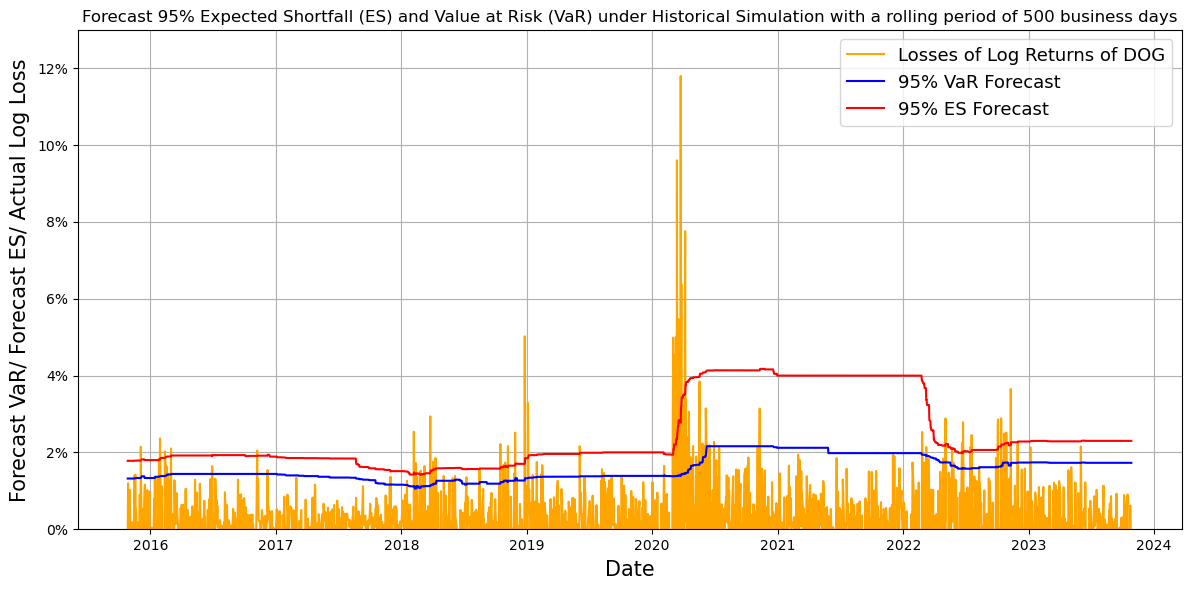

In [20]:
# Plot 1

fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 95% Expected Shortfall (ES) and Value at Risk (VaR) under Historical Simulation with a rolling period of 500 business days")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(hs_VaR_test_forecasts_95, label = "95% VaR Forecast", color = 'blue')
#plt.scatter(logDOG.loc[hs_VaR_test_forecasts_95.index][hs_VaR_breaches_95].index, logDOG.loc[hs_VaR_test_forecasts_95.index][hs_VaR_breaches_95].values, color = 'red', alpha = 0.5, label = 'VaR Forecast Violation')
plt.plot(hs_ES_test_forecasts_95, color = 'red', label = "95% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)
plt.savefig('plot_1_hs_95.png')
plt.show()



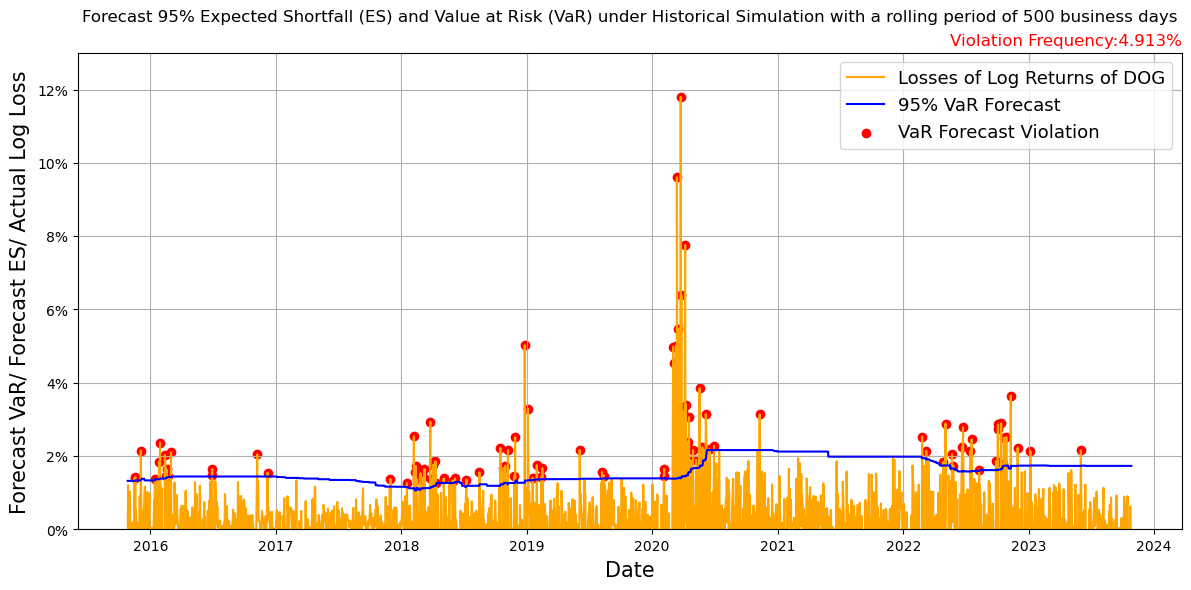

In [53]:
# Plot 2
fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 95% Expected Shortfall (ES) and Value at Risk (VaR) under Historical Simulation with a rolling period of 500 business days", y = 1.05)
plt.title("Violation Frequency:" + str(round(99/2015*100, 3)) +"%", loc = 'right', color = 'red')
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(hs_VaR_test_forecasts_95, label = "95% VaR Forecast", color = 'blue')
plt.scatter(logDOG.loc[hs_VaR_test_forecasts_95.index][hs_VaR_breaches_95].index, logDOG.loc[hs_VaR_test_forecasts_95.index][hs_VaR_breaches_95].values, color = 'red', label = 'VaR Forecast Violation')
#plt.plot(hs_ES_test_forecasts_95, color = 'red', label = "95% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)
plt.savefig('plot_2_hs_var_95_breaches')
plt.show()



Now under EWMA Filtered Historical Simulation:

In [22]:
def ewma_vaR_Forecast(data, rolling_window, alpha, var, empirical_observations):

    expected_shortfalls = np.empty(np.size(data)- rolling_window)

    for i in range(0, len(expected_shortfalls)):
        expected_shortfalls[i] = ewma_vaR(data.iloc[i: i+rolling_window], alpha, var, empirical_observations)

        # print(i)
        # print(expected_shortfalls[i])
        # print(data.iloc[i: i + rolling_window])

        #



    expected_shortfalls = pd.DataFrame(expected_shortfalls).set_index(data.iloc[rolling_window:].index)

    return expected_shortfalls

In [23]:
def ewma_ES_Forecast(data, rolling_window, alpha, var, empirical_observations):
    """
    Returns EWMA ES Forecast given data, rolling window, variance forecasts, var and empirical observations, as a data frame
    data is the loss data, a pandas data series with dates at the index, and losses as the values
    rolling window is the size of the rolling window to be evaluated
    alpha is the alpha level of the VaR threshold
    var is a data series of calculated variances for the data (outside of the function, as this is pre calculated), with dates as the index, and variances as the values
    empirical observations are the empirical observations of the residuals of the distribution based on the variances. (Again to be pre_calculated for repeated calls), with dates as the index, observations as the values
    """

    expected_shortfalls = np.empty(np.size(data)- rolling_window)

    for i in range(0, len(expected_shortfalls)):
        expected_shortfalls[i] = ewma_ES(data.iloc[i: i+rolling_window], alpha, var, empirical_observations)
        
        # Why is this not working lol

        # print(i)
        # print(expected_shortfalls[i])
        # print(data.iloc[i: i + rolling_window])

        #


    expected_shortfalls = pd.DataFrame(expected_shortfalls).set_index(data.iloc[rolling_window:].index)

    return expected_shortfalls

#ES_test_forecasts = ewma_ES_Forecast(logDOG.iloc[0:-1], 500, 0.99, var, empirical_observations)

Now plot as before:

In [24]:
ewma_ES_test_forecasts_99 = ewma_ES_Forecast(logDOG, 500, 0.99, var, empirical_observations)
ewma_VaR_test_forecasts_99 = ewma_vaR_Forecast(logDOG, 500, 0.99, var, empirical_observations)

ewma_VaR_breaches_99 = logDOG.loc[ewma_VaR_test_forecasts_99.index].values > ewma_VaR_test_forecasts_99.values

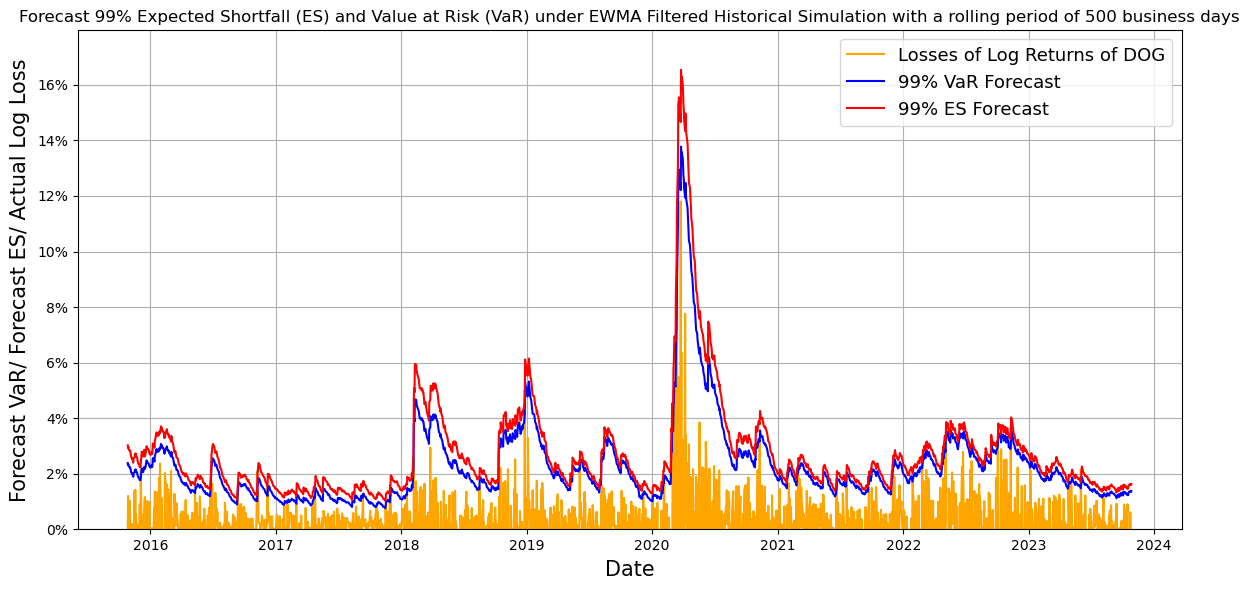

In [25]:
#plot 9

fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 99% Expected Shortfall (ES) and Value at Risk (VaR) under EWMA Filtered Historical Simulation with a rolling period of 500 business days")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(ewma_VaR_test_forecasts_99, label = "99% VaR Forecast", color = 'blue')
#plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_99.index][ewma_VaR_breaches_99].index, logDOG.loc[ewma_VaR_test_forecasts_99.index][ewma_VaR_breaches_99].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
plt.plot(ewma_ES_test_forecasts_99, color = 'red', label = "99% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)

plt.savefig('plot_9_ewma99.png')

plt.show()

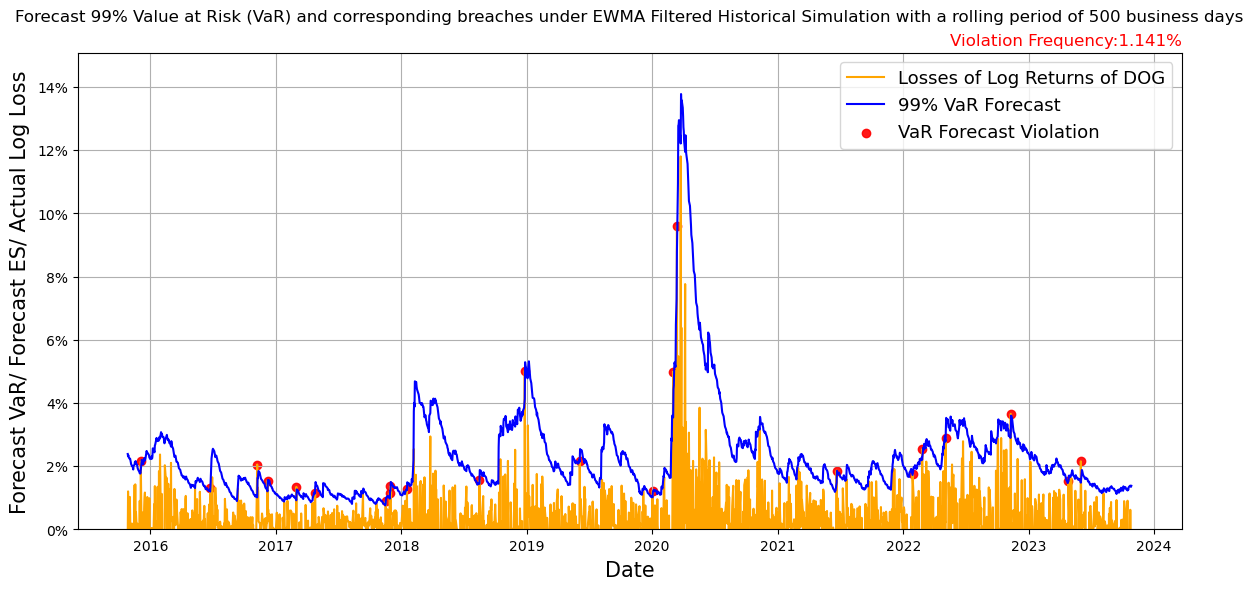

In [54]:
#plot 10

fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 99% Value at Risk (VaR) and corresponding breaches under EWMA Filtered Historical Simulation with a rolling period of 500 business days", y = 1.05)
plt.title("Violation Frequency:" + str(round(23/2015*100, 3)) +"%", loc = 'right', color = 'red')
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(ewma_VaR_test_forecasts_99, label = "99% VaR Forecast", color = 'blue')
plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_99.index][ewma_VaR_breaches_99].index, logDOG.loc[ewma_VaR_test_forecasts_99.index][ewma_VaR_breaches_99].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
# plt.plot(ewma_ES_test_forecasts_99, color = 'red', label = "99% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)

plt.savefig('plot_10_ewma99_breaches.png')

plt.show()

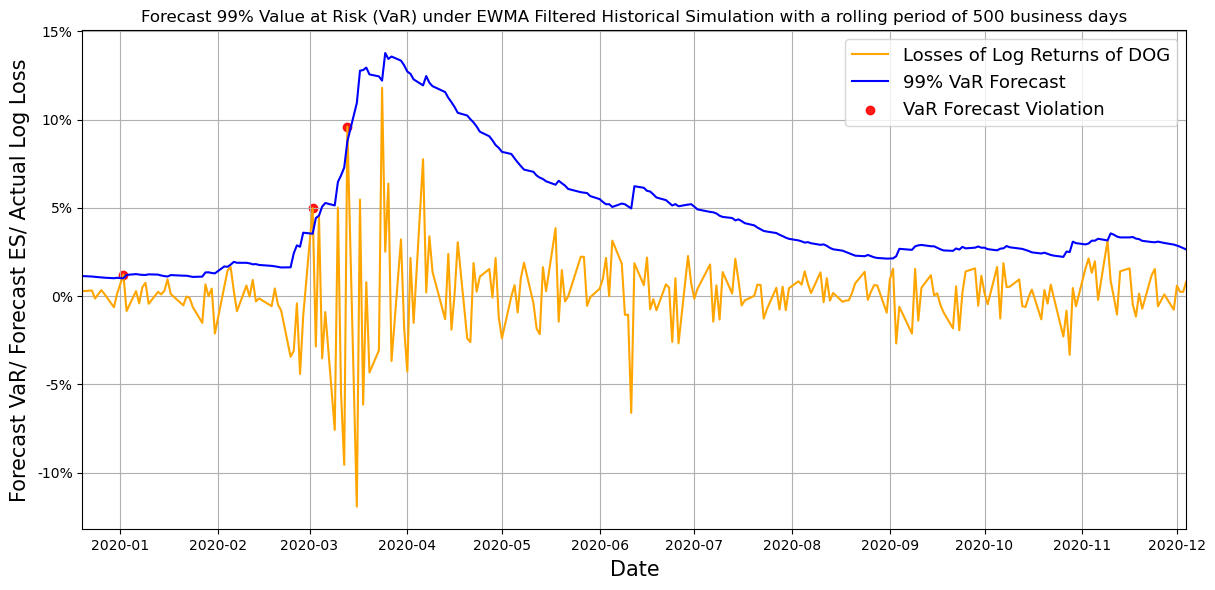

In [27]:
#plot 13

fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 99% Value at Risk (VaR) under EWMA Filtered Historical Simulation with a rolling period of 500 business days")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(ewma_VaR_test_forecasts_99, label = "99% VaR Forecast", color = 'blue')
plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_99.index][ewma_VaR_breaches_99].index, logDOG.loc[ewma_VaR_test_forecasts_99.index][ewma_VaR_breaches_99].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
# plt.plot(ewma_ES_test_forecasts_99, color = 'red', label = "99% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.xlim(left = 18250, right = 18600)

plt.savefig('plot_13_ewma99_jump.png')

plt.show()

In [28]:
ewma_ES_test_forecasts_95 = ewma_ES_Forecast(logDOG, 500, 0.95, var, empirical_observations)
ewma_VaR_test_forecasts_95 = ewma_vaR_Forecast(logDOG, 500, 0.95, var, empirical_observations)

ewma_VaR_breaches_95 = logDOG.loc[ewma_VaR_test_forecasts_95.index].values > ewma_VaR_test_forecasts_95.values



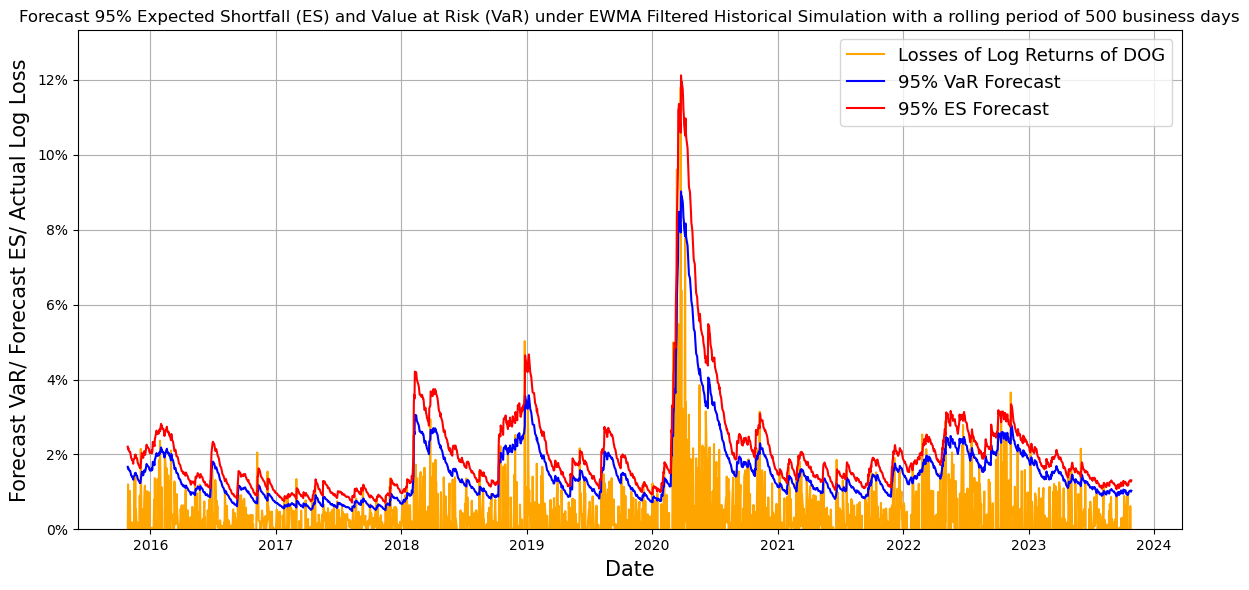

In [29]:
# plot 11
fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 95% Expected Shortfall (ES) and Value at Risk (VaR) under EWMA Filtered Historical Simulation with a rolling period of 500 business days")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(ewma_VaR_test_forecasts_95, label = "95% VaR Forecast", color = 'blue')
#plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].index, logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
plt.plot(ewma_ES_test_forecasts_95, color = 'red', label = "95% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)

plt.savefig('plot_11_ewma95.png')
plt.show()

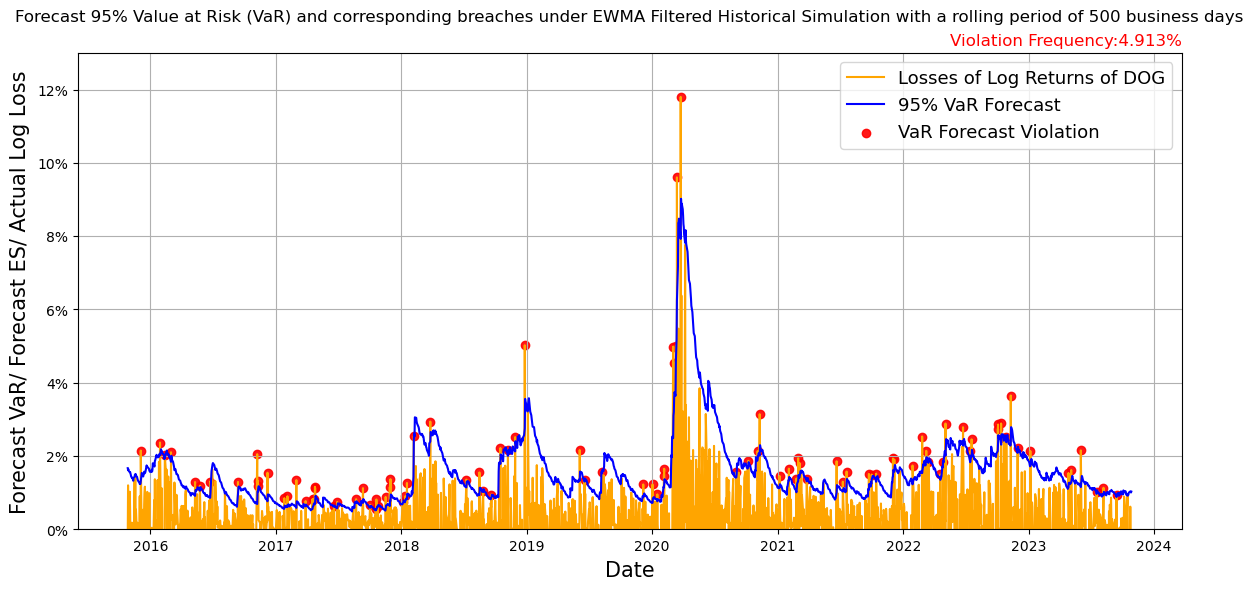

In [55]:
# plot 12

fig = plt.figure(figsize = (12, 6))
plt.title("Forecast 95% Value at Risk (VaR) and corresponding breaches under EWMA Filtered Historical Simulation with a rolling period of 500 business days", y = 1.05)
plt.title("Violation Frequency:" + str(round(99/2015*100, 3)) +"%", loc = 'right', color = 'red')
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.iloc[500:], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(ewma_VaR_test_forecasts_95, label = "95% VaR Forecast", color = 'blue')
plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].index, logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
#plt.plot(ewma_ES_test_forecasts_95, color = 'red', label = "95% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)
plt.savefig('plot_12_ewma95_breaches.png')
plt.show()

Now implementing hypothesis tests on the data

In [31]:
from scipy.stats import chi2

# function for conducting hypothesis tests with respect to VaR
def hypothesis_test(loss_arr, VaR_arr, T, q=0.95, mode='unconditional'):
    """
    Function for conducting hypothesis tests with respect to VaR.
    Input:
    loss_arr: the numpy array of loss of the portfolio (length: N).
    VaR_arr: the numpy array of VaR using a rolling window method (length: N-T).
    T: size of rolling window.
    q: the quantile level for the test.
    mode: 'unconditional' for unconditional coverage test, and 'independence' for 
    independence test.
    Output:
    p_value: the p_value of the test.
    """
    loss_reduced = np.array(loss_arr[T:])
    # VaR violations
    I_arr = np.array([1 if a > b else 0 for a, b in zip(loss_reduced, VaR_arr)])

    # unconditional coverage
    if mode == 'unconditional':
        pi_hat = np.sum(I_arr) / len(I_arr)
        val_tmp = 1
        for p in range(len(I_arr)):
            val_tmp = val_tmp * (q**(1-I_arr[p]) * (1-q)**(I_arr[p])) / ((1-pi_hat)**(1-I_arr[p]) * pi_hat**(I_arr[p]))
        LR_uc = -2* np.log(val_tmp)
        p_value = 1 - chi2.cdf(LR_uc, 1)

    # independence test
    elif mode == 'independence':
        val_00 = 0
        val_01 = 0
        val_10 = 0
        val_11 = 0
        for r in range(1, len(I_arr)):
            if I_arr[r-1] == 0 and I_arr[r] == 0:
                val_00 += 1
            elif I_arr[r-1] == 0 and I_arr[r] == 1:
                val_01 += 1
            elif I_arr[r-1] == 1 and I_arr[r] == 0:
                val_10 += 1
            elif I_arr[r-1] == 1 and I_arr[r] == 1:
                val_11 += 1

        pi_11_hat = val_11 / (val_10 + val_11)
        pi_01_hat = val_01 / (val_00 + val_01)
        pi_hat = np.sum(I_arr) / len(I_arr)

        val_tmp = ((1-pi_hat)**(val_00 + val_10) * (pi_hat)**(val_01 + val_11)) / ((1-pi_01_hat)**val_00 * pi_01_hat**val_01 * (1-pi_11_hat)**val_10 * pi_11_hat**val_11)
        LR_uc = -2* np.log(val_tmp)
        p_value = 1 - chi2.cdf(LR_uc, 1)

    else:
        print("Mode not correctly selected")
    
    return p_value

hs_p_list = [hypothesis_test(logDOG.values, hs_VaR_test_forecasts_95.values, 500, 0.95), hypothesis_test(logDOG.values, hs_VaR_test_forecasts_99.values, 500, 0.99),hypothesis_test(logDOG.values, hs_VaR_test_forecasts_95.values, 500, 0.95, mode = 'independence'), hypothesis_test(logDOG.values, hs_VaR_test_forecasts_99.values, 500, 0.99, mode = 'independence')]
expected_violations = [len(logDOG.values[500:])*0.05, len(logDOG.values[500:])*0.01, len(logDOG.values[500:])*0.05, len(logDOG.values[500:])*0.01]
hs_actual_violations = [hs_VaR_breaches_95.sum(), hs_VaR_breaches_99.sum(), hs_VaR_breaches_95.sum(), hs_VaR_breaches_99.sum()]
ewma_p_list = [hypothesis_test(logDOG.values, ewma_VaR_test_forecasts_95.values, 500, 0.95), hypothesis_test(logDOG.values, ewma_VaR_test_forecasts_99.values, 500, 0.99),hypothesis_test(logDOG.values, ewma_VaR_test_forecasts_95.values, 500, 0.95, mode='independence'), hypothesis_test(logDOG.values, ewma_VaR_test_forecasts_99.values, 500, 0.99, mode = 'independence')]
ewma_actual_violations =[ewma_VaR_breaches_95.sum(), ewma_VaR_breaches_99.sum(), ewma_VaR_breaches_95.sum(), ewma_VaR_breaches_99.sum()]

In [32]:
print("Expected Violations")
print(expected_violations)
print("Actual HS Violations")
print(hs_actual_violations)
print("Actual EWMA Violations")
print(ewma_actual_violations)
print("HS P List")
print(hs_p_list)
print("EWMA P list")
print(ewma_p_list)


Expected Violations
[100.75, 20.150000000000002, 100.75, 20.150000000000002]
Actual HS Violations
[99, 30, 99, 30]
Actual EWMA Violations
[99, 23, 99, 23]
HS P List
[0.8576464810869835, 0.039755186019194366, 0.02977550992646083, 0.08045481917211328]
EWMA P list
[0.857646481086986, 0.5326095139969101, 0.6707972696453615, 0.4660151671174103]


In [33]:
# function for conducting hypothesis tests with respect to VaR
def hypothesis_test_VaR(loss_arr, VaR_arr, T, q=0.95, mode='unconditional'):
    """
    Function for conducting hypothesis tests with respect to VaR.
    Input:
    loss_arr: the numpy array of loss of the portfolio (length: N).
    VaR_arr: the numpy array of VaR using a rolling window method (length: N-T).
    T: size of rolling window.
    q: the quantile level for the test.
    mode: 'unconditional' for unconditional coverage test, and 'independence' for 
    independence test.
    Output:
    p_value: the p_value of the test
    """
    loss_reduced = np.array(loss_arr[T:])
    # VaR violations
    I_arr = np.array([1 if a > b else 0 for a, b in zip(loss_reduced, VaR_arr)])
    violation_tuple = tuple((np.sum(I_arr), len(loss_reduced), np.sum(I_arr)/len(loss_reduced)))

    # unconditional coverage
    if mode == 'unconditional':
        pi_hat = np.sum(I_arr) / len(I_arr)
        val_tmp = 1
        for p in range(len(I_arr)):
            val_tmp = val_tmp * (q**(1-I_arr[p]) * (1-q)**(I_arr[p])) / ((1-pi_hat)**(1-I_arr[p]) * pi_hat**(I_arr[p]))
        LR_uc = -2 * np.log(val_tmp)
        p_value = 1 - chi2.cdf(LR_uc, 1)

    # independence test
    elif mode == 'independence':
        val_00 = 0
        val_01 = 0
        val_10 = 0
        val_11 = 0
        for r in range(1, len(I_arr)):
            if I_arr[r-1] == 0 and I_arr[r] == 0:
                val_00 += 1
            elif I_arr[r-1] == 0 and I_arr[r] == 1:
                val_01 += 1
            elif I_arr[r-1] == 1 and I_arr[r] == 0:
                val_10 += 1
            elif I_arr[r-1] == 1 and I_arr[r] == 1:
                val_11 += 1

        pi_11_hat = val_11 / (val_10 + val_11)
        pi_01_hat = val_01 / (val_00 + val_01)
        pi_hat = np.sum(I_arr) / len(I_arr)

        val_tmp = ((1-pi_hat)**(val_00 + val_10) * (pi_hat)**(val_01 + val_11)) / ((1-pi_01_hat)**val_00 * pi_01_hat**val_01 * (1-pi_11_hat)**val_10 * pi_11_hat**val_11)
        LR_uc = -2 * np.log(val_tmp)
        p_value = 1 - chi2.cdf(LR_uc, 1)

    return violation_tuple, LR_uc, p_value



# function for conducting hypothesis tests with respect to ES
def hypothesis_test_ES(loss_arr, VaR_arr, ES_arr, T):
    """
    Function for conducting hypothesis tests with respect to VaR.
    Input:
    loss_arr: the numpy array of loss of the portfolio (length: N).
    VaR_arr: the numpy array of VaR using a rolling window method (length: N-T).
    T: size of rolling window.
    q: the quantile level for the test.
    mode: 'unconditional' for unconditional coverage test, and 'independence' for 
    independence test.
    Output:
    p_value: the p_value of the test
    """
    loss_reduced = np.array(loss_arr[T:])
    # VaR violations
    I_arr = np.array([1 if a > b else 0 for a, b in zip(loss_reduced, VaR_arr)])
    e_arr = (loss_reduced - ES_arr) * I_arr
    # violation_tuple = tuple((np.sum(I_arr), len(loss_reduced), np.sum(I_arr)/len(loss_reduced)))
    val_tmp_1 = np.sum(e_arr)
    val_tmp_2 = np.sqrt(np.sum(e_arr**2))
    z = val_tmp_1 / val_tmp_2
    p_value = 1 - norm.cdf(z)

    return p_value

Thomas's edited version

In [34]:
# function for conducting hypothesis tests with respect to VaR
def TP_hypothesis_test_VaR(loss_arr, VaR_arr, breaches, q=0.95, mode='unconditional', debug = False):
    """
    Function for conducting hypothesis tests with respect to VaR.
    Input:
    loss_arr: daily loss of the portfolio, data frame of losses with index as date
    VaR_arr: daily VaR forecasts of the portfolio, data frame of losses with index as date
    breaches: VaR breaches array
    q: the quantile level for the test.
    mode: 'unconditional' for unconditional coverage test, and 'independence' for 
    independence test.
    Output:
    p_value: the p_value of the test
    """
    loss_reduced = loss_arr.loc[VaR_arr.index].values
    # VaR violations
    I_arr = breaches
    violation_tuple = tuple((np.sum(I_arr), len(loss_reduced), np.sum(I_arr)/len(loss_reduced), len(loss_reduced) * (1-q)))

    
    LR_uc = 0
    LR_ind = 0
    # unconditional coverage
    if mode == 'unconditional' or mode == 'joint' or mode == 'all':
        pi_hat = np.sum(I_arr) / len(I_arr)
        
        # We will take logs and add first, since this is usually more stable than multiplying small values
        I_sum = np.sum(I_arr)
        T = len(I_arr)
        log_numerator = (T - I_sum) * np.log(q) + I_sum * np.log(1-q)
        log_denominator = (T - I_sum) * np.log(1 - pi_hat) + I_sum * np.log(pi_hat)

        LR_uc = -2 * (log_numerator - log_denominator)

    # independence test
    if mode == 'independence' or mode == 'joint' or mode == 'all':
        T_00 = 0
        T_01 = 0
        T_10 = 0
        T_11 = 0
        
        for r in range(1, len(I_arr)):
            if I_arr[r-1] == 0 and I_arr[r] == 0:
                T_00 += 1
            elif I_arr[r-1] == 0 and I_arr[r] == 1:
                T_01 += 1
            elif I_arr[r-1] == 1 and I_arr[r] == 0:
                T_10 += 1
            elif I_arr[r-1] == 1 and I_arr[r] == 1:
                T_11 += 1

        pi_11_hat = T_11 / (T_10 + T_11)
        pi_01_hat = T_01 / (T_00 + T_01)
        pi_hat = np.sum(I_arr) / len(I_arr)

        if debug:
            print("T00, T01, T10, T11")
            print((T_00, T_01, T_10, T_11))
            print("pi10hat, p11hat")
            print((pi_01_hat, pi_11_hat))
            print("pihat")
            print(pi_hat)

        if T_11 == 0:
            LR_ind = 2 * (T_00 * np.log(1-pi_01_hat) + T_01 * np.log(pi_01_hat) + T_10 * np.log(1 - pi_11_hat) + T_11 - (T_00 * np.log(1-pi_hat) + T_01 * np.log(pi_hat) + T_10 * np.log(1 - pi_hat) + T_11 * np.log(pi_hat)))
        else:
            LR_ind = 2 * (T_00 * np.log(1-pi_01_hat) + T_01 * np.log(pi_01_hat) + T_10 * np.log(1 - pi_11_hat) + T_11 * np.log(pi_11_hat) - (T_00 * np.log(1-pi_hat) + T_01 * np.log(pi_hat) + T_10 * np.log(1 - pi_hat) + T_11 * np.log(pi_hat)))

    if mode == 'all':
        return violation_tuple, LR_uc, 1 - chi2.cdf(LR_uc, 1), LR_ind, 1 - chi2.cdf(LR_ind, 1), LR_ind + LR_uc, 1 - chi2.cdf(LR_uc + LR_ind, 2)
    if mode == 'joint':
        return violation_tuple, LR_ind + LR_uc, 1 - chi2.cdf(LR_uc + LR_ind, 2)
    return violation_tuple, LR_uc + LR_ind, 1 - chi2.cdf(LR_ind + LR_uc, 1)

We now implement the method on our data

In [35]:
print("Jerry's Versions, for comparison")
print(hypothesis_test_VaR(logDOG.values, hs_VaR_test_forecasts_95.values, 500, 0.95, 'unconditional'))
print(hypothesis_test_VaR(logDOG.values, hs_VaR_test_forecasts_95.values, 500, 0.95, 'independence'))
print("**********************************************")
print("For 95 historical VaR, Unconditional, Independent and Joint:")
print(TP_hypothesis_test_VaR(logDOG, hs_VaR_test_forecasts_95, hs_VaR_breaches_95, 0.95, 'all'))

print("For 99 historical VaR, Unconditional, Independent and Joint:")
print(TP_hypothesis_test_VaR(logDOG, hs_VaR_test_forecasts_99, hs_VaR_breaches_99, 0.99, 'all'))

print("For 95 EWMA VaR, Unconditional, Independent and Joint:")
print(TP_hypothesis_test_VaR(logDOG, ewma_VaR_test_forecasts_95, ewma_VaR_breaches_95, 0.95, 'all'))

# Something is going wrong here... why did we have to divide by zero? Because we had no repeat VaR violations, so T11 is 0.
print("For 99 EWMA VaR, Unconditional, Independent and Joint:")
print(TP_hypothesis_test_VaR(logDOG, ewma_VaR_test_forecasts_99, ewma_VaR_breaches_99, 0.99, 'all'))



Jerry's Versions, for comparison
((99, 2015, 0.04913151364764268), 0.032173918923779195, 0.8576464810869835)
((99, 2015, 0.04913151364764268), 4.722206617300618, 0.02977550992646083)
**********************************************
For 95 historical VaR, Unconditional, Independent and Joint:
((99, 2015, 0.04913151364764268, 100.75000000000009), 0.03217391892383148, 0.8576464810868691, 4.722206617300458, 0.029775509926463495, 4.754380536224289, 0.09281098548619238)
For 99 historical VaR, Unconditional, Independent and Joint:
((30, 2015, 0.01488833746898263, 20.150000000000016), 4.228302334382931, 0.039755186019193145, 3.0556899213906377, 0.08045481917211483, 7.283992255773569, 0.026199993196602378)
For 95 EWMA VaR, Unconditional, Independent and Joint:
((99, 2015, 0.04913151364764268, 100.75000000000009), 0.03217391892383148, 0.8576464810868691, 0.1806709500586976, 0.6707972696453179, 0.21284486898252908, 0.8990447803225529)
For 99 EWMA VaR, Unconditional, Independent and Joint:
((23, 201

In [36]:
from scipy.stats import norm

# function for conducting hypothesis tests with respect to ES
def TP_ES_back_testing(loss_arr, VaR_arr, ES_arr, breaches):
    """
    Function for conducting hypothesis tests with respect to VaR.
    Input:
    loss_arr: the numpy array of loss of the portfolio (length: N).
    VaR_arr: the numpy array of VaR using a rolling window method (length: N-T).
    T: size of rolling window.
    q: the quantile level for the test.
    mode: 'unconditional' for unconditional coverage test, and 'independence' for 
    independence test.
    Output:
    p_value: the p_value of the test
    """
    loss_reduced = loss_arr.loc[VaR_arr.index].values
    # VaR violations
    I_arr = breaches
    e_arr = (loss_reduced - ES_arr.values) * I_arr
    # violation_tuple = tuple((np.sum(I_arr), len(loss_reduced), np.sum(I_arr)/len(loss_reduced)))
    val_tmp_1 = np.sum(e_arr)
    #print(e_arr)
    #print(val_tmp_1)
    val_tmp_2 = np.sqrt(np.sum(e_arr**2))
    #print(val_tmp_2)
    z = val_tmp_1 / val_tmp_2

    #print(z)
    p_value = 1 - norm.cdf(z)

    return z, p_value

In [37]:
pd.DataFrame(ewma_VaR_breaches_99).to_csv('ewma99breaches')

In [38]:
# To work out why the array lengths don't match tomorrow

print("Historical 95 Backtest")
print(TP_ES_back_testing(logDOG, hs_VaR_test_forecasts_95, hs_ES_test_forecasts_95, hs_VaR_breaches_95))
print("Historical 99 Backtest")
print(TP_ES_back_testing(logDOG, hs_VaR_test_forecasts_99, hs_ES_test_forecasts_99, hs_VaR_breaches_99))
print("EWMA 95 Backtest")
print(TP_ES_back_testing(logDOG, ewma_VaR_test_forecasts_95, ewma_ES_test_forecasts_95, ewma_VaR_breaches_95))
print("EWMA 99 Backtest")
print(TP_ES_back_testing(logDOG, ewma_VaR_test_forecasts_99, ewma_ES_test_forecasts_99, ewma_VaR_breaches_99))

Historical 95 Backtest
(1.1248035907570058, 0.13033613626606666)
Historical 99 Backtest
(1.7795688815882758, 0.0375732713475061)
EWMA 95 Backtest
(0.24598306540707957, 0.4028476708305314)
EWMA 99 Backtest
(-0.8298410186253827, 0.7966856620494098)


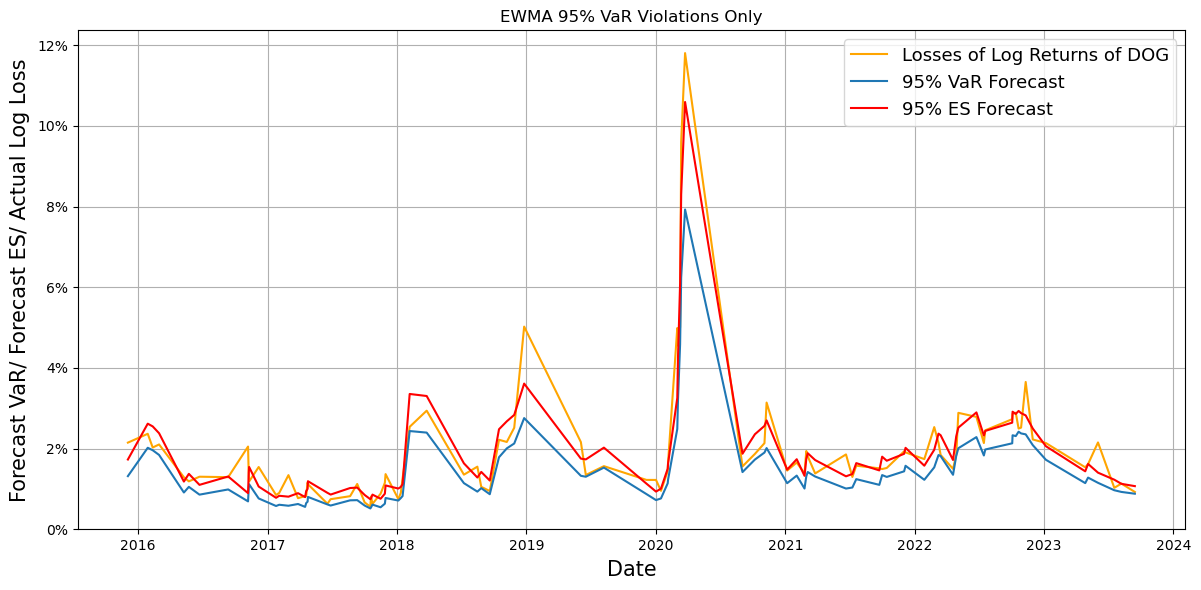

In [39]:
fig = plt.figure(figsize = (12, 6))
plt.title("EWMA 95% VaR Violations Only")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(ewma_VaR_test_forecasts_95.loc[ewma_VaR_breaches_95], label = "95% VaR Forecast")
#plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].index, logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
plt.plot(ewma_ES_test_forecasts_95.loc[ewma_VaR_breaches_95], color = 'red', label = "95% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)

plt.show()

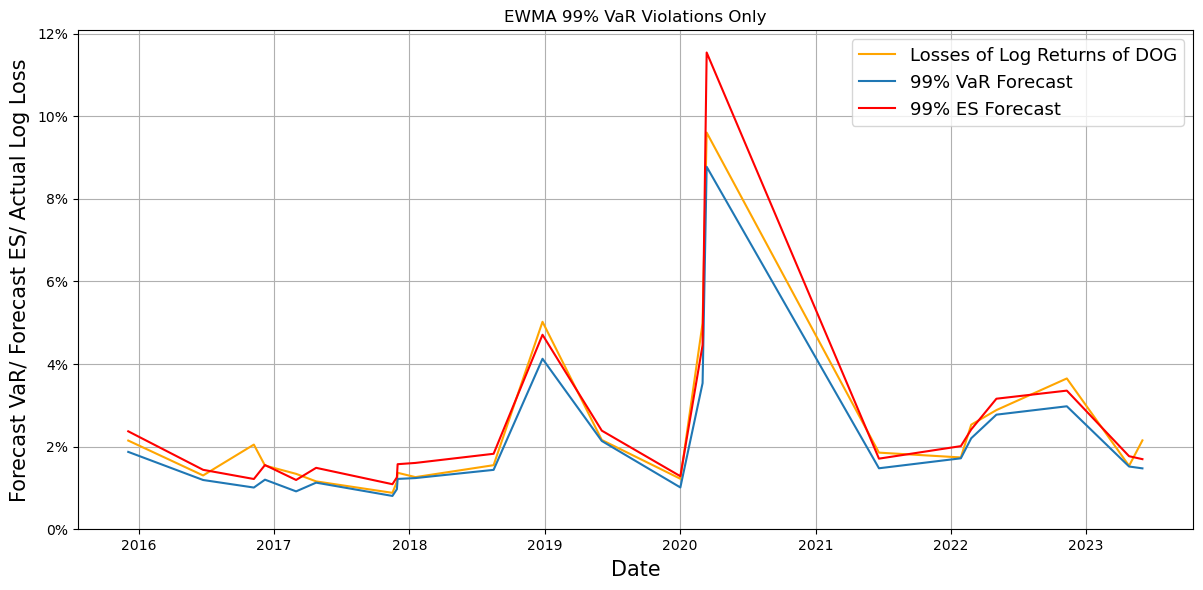

In [40]:
fig = plt.figure(figsize = (12, 6))
plt.title("EWMA 99% VaR Violations Only")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.loc[ewma_VaR_test_forecasts_99.index][ewma_VaR_breaches_99], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(ewma_VaR_test_forecasts_99.loc[ewma_VaR_breaches_99], label = "99% VaR Forecast")
#plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].index, logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
plt.plot(ewma_ES_test_forecasts_99.loc[ewma_VaR_breaches_99], color = 'red', label = "99% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)

plt.show()

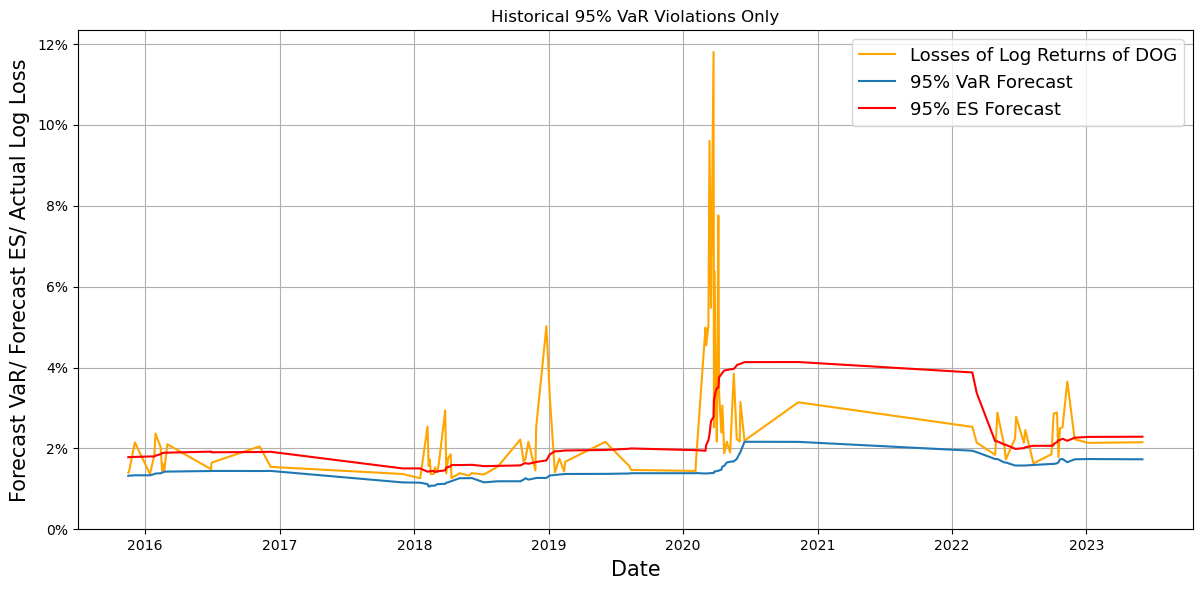

In [41]:
fig = plt.figure(figsize = (12, 6))
plt.title("Historical 95% VaR Violations Only")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.loc[hs_VaR_test_forecasts_95.index][hs_VaR_breaches_95], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(hs_VaR_test_forecasts_95.loc[hs_VaR_breaches_95], label = "95% VaR Forecast")
#plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].index, logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
plt.plot(hs_ES_test_forecasts_95.loc[hs_VaR_breaches_95], color = 'red', label = "95% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)

plt.show()

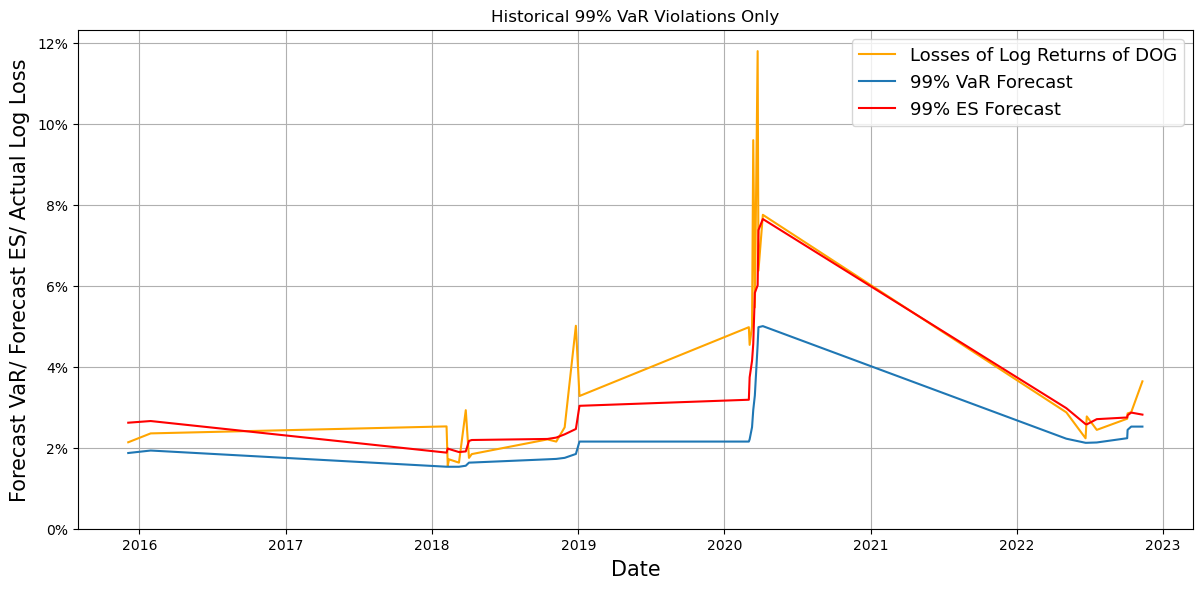

In [42]:
fig = plt.figure(figsize = (12, 6))
plt.title("Historical 99% VaR Violations Only")
plt.grid(True)

plt.xlabel("Date", fontsize = 15, labelpad = 5)
plt.ylabel("Forecast VaR/ Forecast ES/ Actual Log Loss", fontsize = 15, labelpad= 5)
plt.plot(logDOG.loc[hs_VaR_test_forecasts_99.index][hs_VaR_breaches_99], color = 'orange', label = "Losses of Log Returns of DOG")
plt.plot(hs_VaR_test_forecasts_99.loc[hs_VaR_breaches_99], label = "99% VaR Forecast")
#plt.scatter(logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].index, logDOG.loc[ewma_VaR_test_forecasts_95.index][ewma_VaR_breaches_95].values, color = 'red', alpha = 0.9, label = 'VaR Forecast Violation')
plt.plot(hs_ES_test_forecasts_99.loc[hs_VaR_breaches_99], color = 'red', label = "99% ES Forecast")
plt.legend(fontsize = 13)
plt.tight_layout()

def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.ylim(bottom = 0)

plt.show()

Connected to ic_math (Python 3.12.0)

In [1]:
# This is the code implementation of Quantitive Qisk Management Coursework Part B
import numpy as np
import pandas as pd
from arch.univariate import arch_model
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from scipy.stats import chi2, norm

In [2]:
# (iii)
# import the data
data_b = pd.read_csv('QRM-2024-cw1-data-b.csv')

close_series = data_b['Adj Close']
time_arr = np.array(data_b['Date'][1:])

# compute the log return vector
return_series = -100 * np.log(close_series).diff()
x = return_series.dropna()  # get rid of the NaN component

# implement the risk measures for the first rolling window
init_index = 0
time_arr_1 = time_arr[init_index:init_index+500]
time_arr_1 = pd.to_datetime(time_arr_1)
# time_arr_1 = np.array([i for i in range(500)])

loss_series_1 = x[init_index:init_index+500]
model_3 = arch_model(loss_series_1, mean='constant', p=1, q=1, dist='normal')

# fit the model
res_3 = model_3.fit(update_freq=3)

# show the fitting results
print(res_3)

# record the estimated parameter values
mu_hat = res_3.params['mu']
alpha_0 = res_3.params['omega']
alpha_1 = res_3.params['alpha[1]']
beta_1 = res_3.params['beta[1]']

T = 500  # rolling window size

# construct arrays for the process
loss_arr_1 = np.array(loss_series_1)
epsilon_arr = loss_arr_1 - mu_hat
z_arr = np.zeros(T)
sig_arr = np.zeros(T)
mu_arr = np.array([mu_hat for _ in range(T)])

# compute the estimates sigma values, and the values of the standardised residuals
for i in range(T):
    if i == 0:
        sig_lag = np.var(loss_arr_1)
        X_lag = np.mean(loss_arr_1)
    else:
        sig_lag = sig_arr[i-1]
        X_lag = loss_arr_1[i-1]

    sig_arr[i] = alpha_0 + alpha_1*(X_lag - mu_hat)**2 + beta_1*sig_lag
    z_arr[i] = epsilon_arr[i] / np.sqrt(sig_arr[i])

# compute the noe step volatility forecast
new_sig = alpha_0 + alpha_1*(loss_arr_1[-1] - mu_hat)**2 + beta_1*sig_arr[-1]
# compute the risk measures
VaR_z = np.quantile(z_arr, 0.95)
ES_z = np.mean(z_arr[z_arr > VaR_z])
VaR = mu_hat + np.sqrt(new_sig) * VaR_z
ES = mu_hat + np.sqrt(new_sig) * ES_z

Iteration:      3,   Func. Count:     20,   Neg. LLF: 569.3787863919224
Iteration:      6,   Func. Count:     41,   Neg. LLF: 548.2715125403802
Iteration:      9,   Func. Count:     56,   Neg. LLF: 548.2475842749244
Optimization terminated successfully    (Exit mode 0)
            Current function value: 548.2475842749507
            Iterations: 9
            Function evaluations: 56
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -548.248
Distribution:                  Normal   AIC:                           1104.50
Method:            Maximum Likelihood   BIC:                           1121.35
                                        No. Observations:                  500
Date:                Wed

<ipython-input-2-06fe512de223>:15: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  time_arr_1 = pd.to_datetime(time_arr_1)


<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<ipython-input-3-3e3294de7cdb>:4: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(time_arr_1, mu_arr, color='blue', label="$\hat{\mu}_t$")


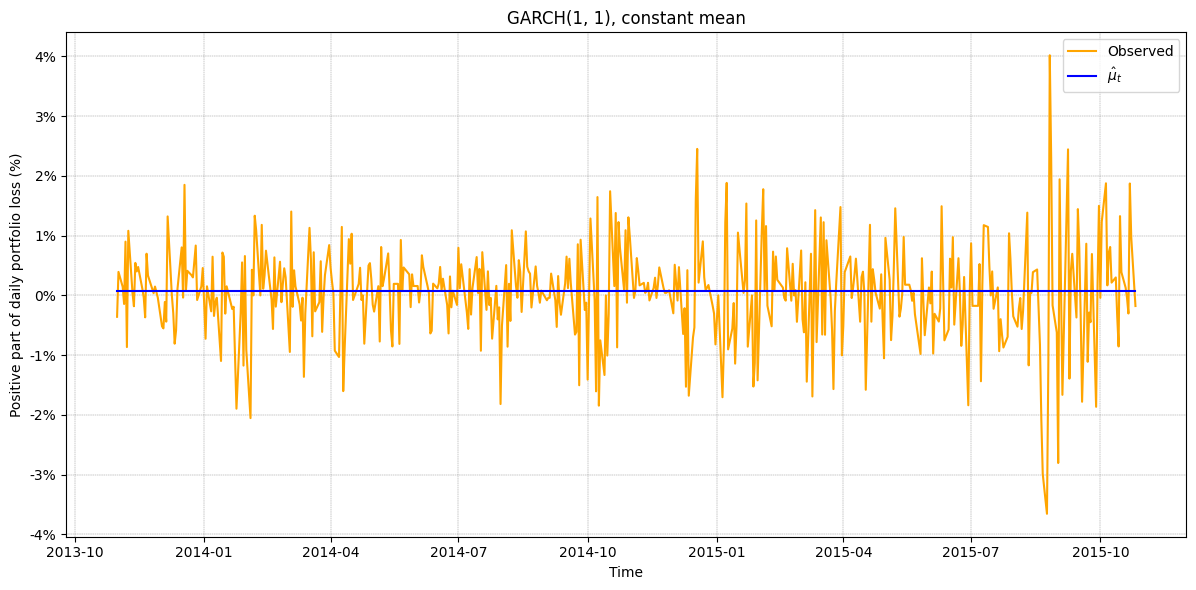

In [3]:
# Plot the time series against the estimated mean of GARCH process
plt.figure(figsize=(12, 6))
plt.plot(time_arr_1, loss_arr_1, color='orange', label="Observed")
plt.plot(time_arr_1, mu_arr, color='blue', label="$\hat{\mu}_t$")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Adding title, labels, and legend
plt.title("GARCH(1, 1), constant mean")
plt.xlabel("Time")
plt.ylabel("Positive part of daily portfolio loss (%)")
plt.legend()

plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<ipython-input-4-8f2b114c2ef0>:4: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(time_arr_1, np.sqrt(sig_arr), color='blue', label="$\hat{\sigma}_t^2$")


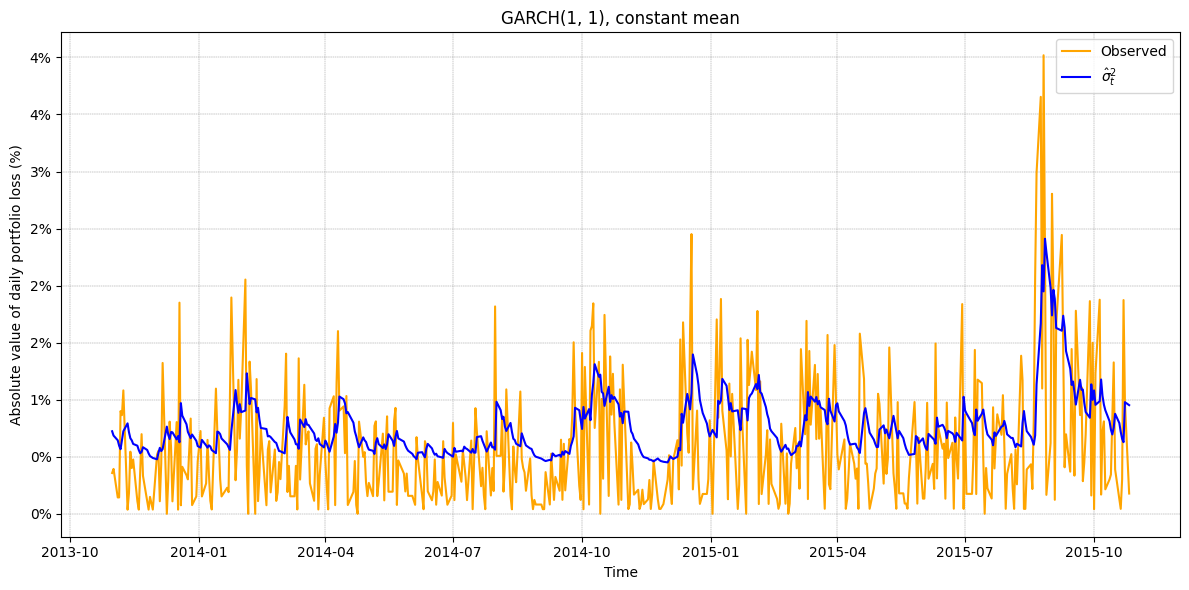

In [4]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(time_arr_1, abs(loss_arr_1), color='orange', label="Observed")
plt.plot(time_arr_1, np.sqrt(sig_arr), color='blue', label="$\hat{\sigma}_t^2$")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Adding title, labels, and legend
plt.title("GARCH(1, 1), constant mean")
plt.xlabel("Time")
plt.ylabel("Absolute value of daily portfolio loss (%)")
plt.legend()

plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

In [5]:
# the function for compute risk measures using a rolling window scheme
def risk_GARCH(x, T, q):
    VaR_list = []
    ES_list = []
    for i in range(T, len(x)):

        # implement the risk measures for the first rolling window
        loss_series_i = x[i-T:i]
        model_i = arch_model(loss_series_i, mean='constant', p=1, q=1, dist='normal')

        # fit the model
        res_i = model_i.fit(update_freq=3)

        # record the estimated parameter values
        mu_hat = res_i.params['mu']
        alpha_0 = res_i.params['omega']
        alpha_1 = res_i.params['alpha[1]']
        beta_1 = res_i.params['beta[1]']

        # construct arrays for the process
        loss_arr_i = np.array(loss_series_i)
        epsilon_arr = loss_arr_i - mu_hat
        z_arr = np.zeros(T)
        sig_arr = np.zeros(T)
        # mu_arr = np.array([mu_hat for _ in range(T)])

        # compute the estimates sigma values, and the values of the standardised residuals
        for j in range(T):
            if j == 0:
                sig_lag = np.var(loss_arr_i)
                X_lag = np.mean(loss_arr_i)
            else:
                sig_lag = sig_arr[j-1]
                X_lag = loss_arr_i[j-1]

            sig_arr[j] = alpha_0 + alpha_1*(X_lag - mu_hat)**2 + beta_1*sig_lag
            z_arr[j] = epsilon_arr[j] / np.sqrt(sig_arr[j])

        # compute the noe step volatility forecast
        new_sig = alpha_0 + alpha_1*(loss_arr_i[-1] - mu_hat)**2 + beta_1*sig_arr[-1]
        # compute the risk measures
        VaR_z = np.quantile(z_arr, q)
        ES_z = np.mean(z_arr[z_arr > VaR_z])
        VaR_i = mu_hat + np.sqrt(new_sig) * VaR_z
        ES_i = mu_hat + np.sqrt(new_sig) * ES_z
        VaR_list.append(VaR_i)
        ES_list.append(ES_i)

    return np.array(VaR_list), np.array(ES_list)

In [6]:
VaR_arr_95, ES_arr_95 = risk_GARCH(x, 500, 0.95)
VaR_arr_99, ES_arr_99 = risk_GARCH(x, 500, 0.99)

Iteration:      3,   Func. Count:     20,   Neg. LLF: 569.3787863919224
Iteration:      6,   Func. Count:     41,   Neg. LLF: 548.2715125403802
Iteration:      9,   Func. Count:     56,   Neg. LLF: 548.2475842749244
Optimization terminated successfully    (Exit mode 0)
            Current function value: 548.2475842749507
            Iterations: 9
            Function evaluations: 56
            Gradient evaluations: 9
Iteration:      3,   Func. Count:     20,   Neg. LLF: 569.5246552299836
Iteration:      6,   Func. Count:     41,   Neg. LLF: 548.4791691757257
Iteration:      9,   Func. Count:     56,   Neg. LLF: 548.455585013251
Optimization terminated successfully    (Exit mode 0)
            Current function value: 548.4555850132641
            Iterations: 9
            Function evaluations: 56
            Gradient evaluations: 9
Iteration:      3,   Func. Count:     20,   Neg. LLF: 570.5974860387738
Iteration:      6,   Func. Count:     41,   Neg. LLF: 549.6978342863863
Iteration: 

In [7]:
time_arr_risk = time_arr[500:]
time_arr_risk = pd.to_datetime(time_arr_risk)
loss_risk = np.array(x[500:])

<ipython-input-7-c9eda3a8e127>:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  time_arr_risk = pd.to_datetime(time_arr_risk)


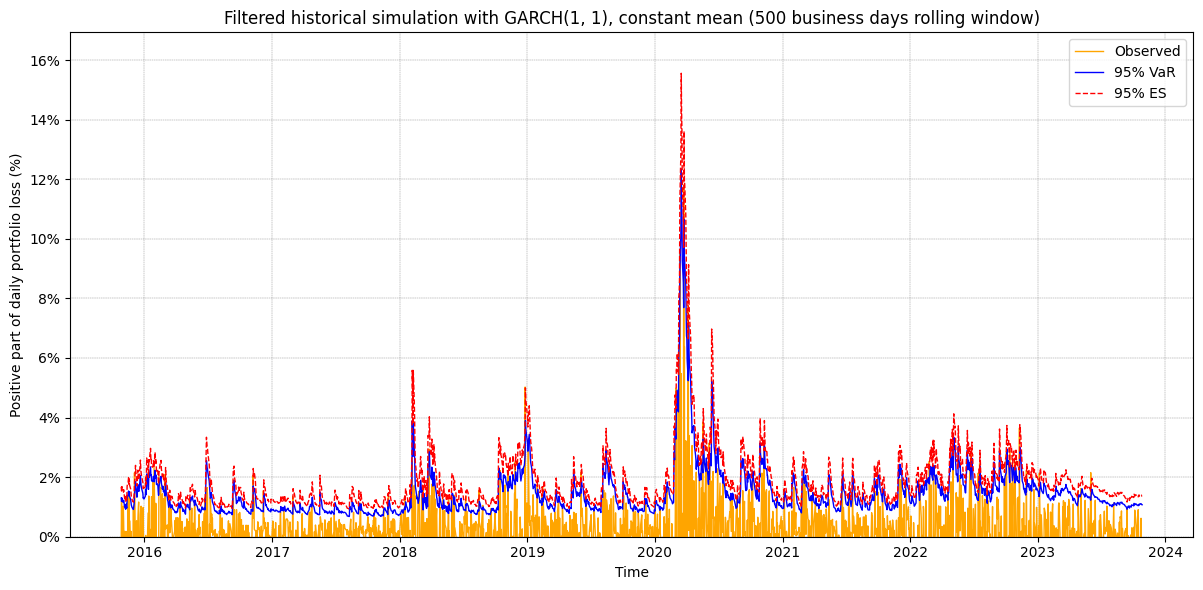

In [8]:
# Plotting at 0.95 level
plt.figure(figsize=(12, 6))
plt.plot(time_arr_risk, loss_risk, label="Observed", linewidth=1, color="orange")
plt.plot(time_arr_risk, VaR_arr_95, label="95% VaR", linewidth=1, color="blue")
plt.plot(time_arr_risk, ES_arr_95, label="95% ES", linewidth=1, color="red", linestyle="--")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Adding title, labels, and legend
plt.title("Filtered historical simulation with GARCH(1, 1), constant mean (500 business days rolling window)")
plt.xlabel("Time")
plt.ylabel("Positive part of daily portfolio loss (%)")
plt.legend()
plt.ylim(0, None)
# plt.ylim(0, 40)

plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

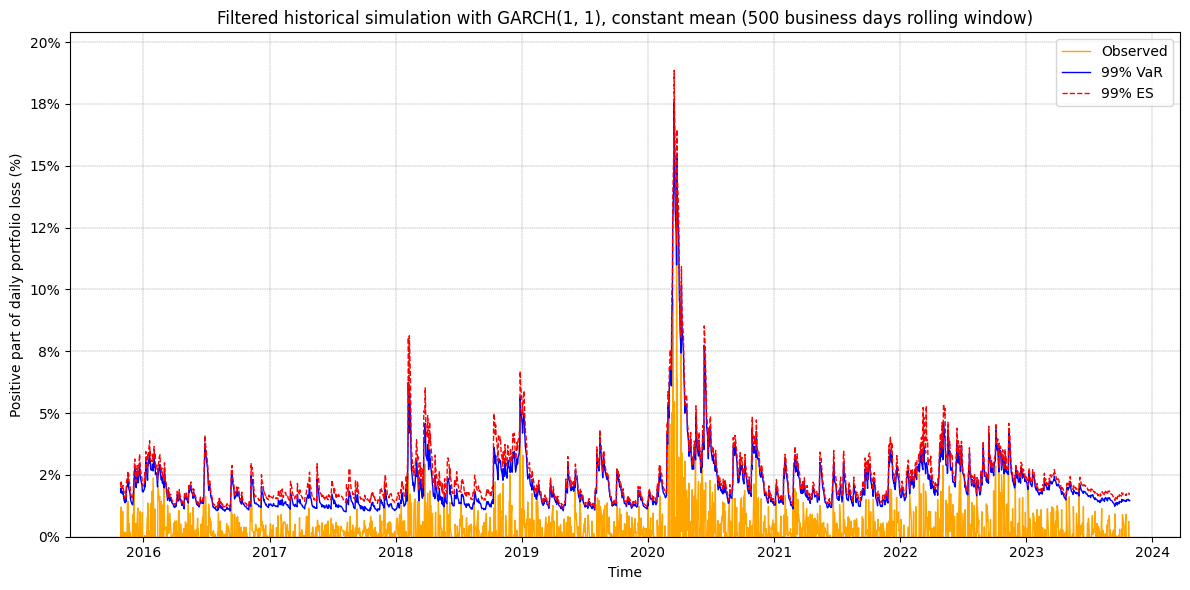

In [9]:
# Plotting at 0.99 level
plt.figure(figsize=(12, 6))
plt.plot(time_arr_risk, loss_risk, label="Observed", linewidth=1, color="orange")
plt.plot(time_arr_risk, VaR_arr_99, label="99% VaR", linewidth=1, color="blue")
plt.plot(time_arr_risk, ES_arr_99, label="99% ES", linewidth=1, color="red", linestyle="--")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Adding title, labels, and legend
plt.title("Filtered historical simulation with GARCH(1, 1), constant mean (500 business days rolling window)")
plt.xlabel("Time")
plt.ylabel("Positive part of daily portfolio loss (%)")
plt.legend()
plt.ylim(0, None)
# plt.ylim(0, 40)

plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

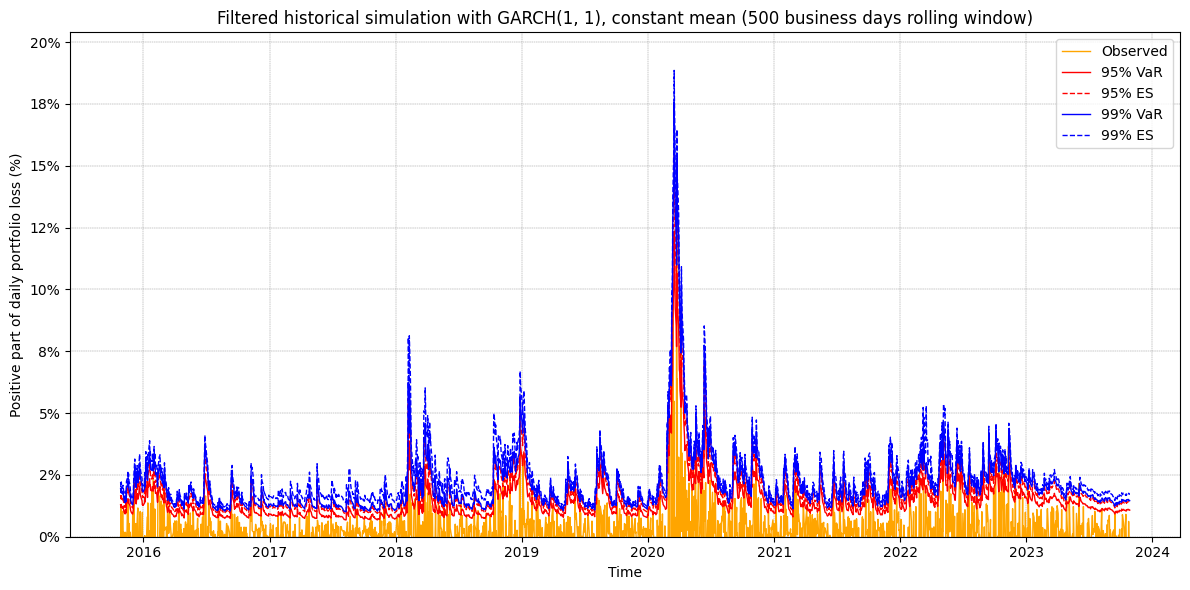

In [10]:
# Plotting at 0.95 and 0.99 level
plt.figure(figsize=(12, 6))
plt.plot(time_arr_risk, loss_risk, label="Observed", linewidth=1, color="orange")
plt.plot(time_arr_risk, VaR_arr_95, label="95% VaR", linewidth=1, color="red")
plt.plot(time_arr_risk, ES_arr_95, label="95% ES", linewidth=1, color="red", linestyle="--")
plt.plot(time_arr_risk, VaR_arr_99, label="99% VaR", linewidth=1, color="blue")
plt.plot(time_arr_risk, ES_arr_99, label="99% ES", linewidth=1, color="blue", linestyle="--")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
# Adding title, labels, and legend
plt.title("Filtered historical simulation with GARCH(1, 1), constant mean (500 business days rolling window)")
plt.xlabel("Time")
plt.ylabel("Positive part of daily portfolio loss (%)")
plt.legend()
plt.ylim(0, None)
# plt.ylim(0, 40)

plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

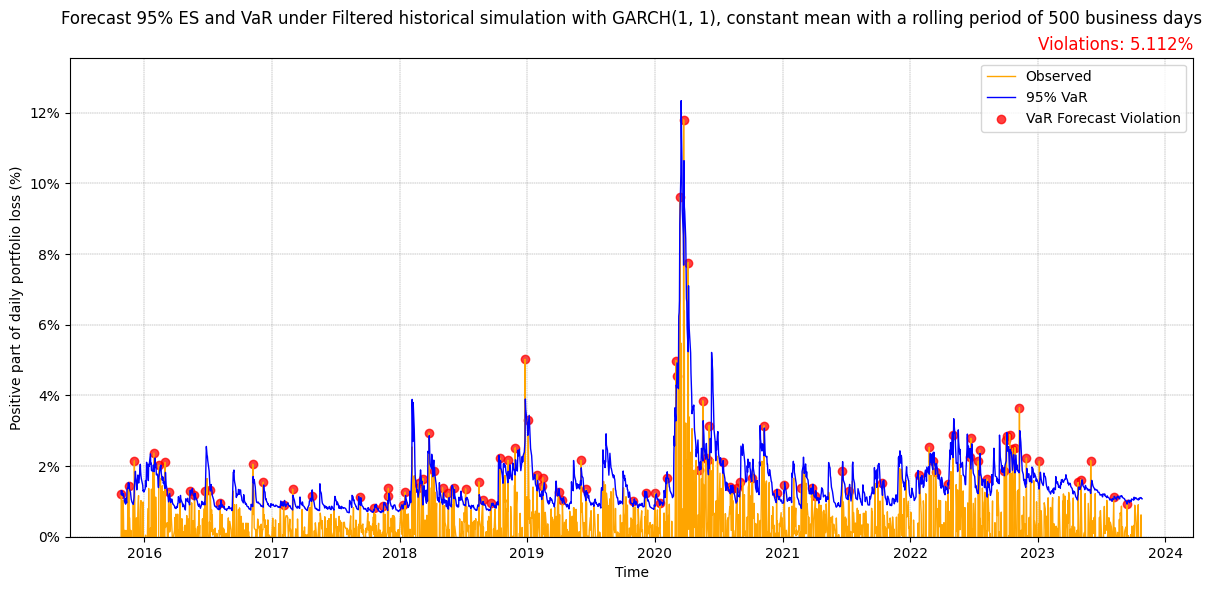

In [11]:
# Plotting the VaR violation at 95% level
violation_index_1 = [True if a > b else False for a, b in zip(loss_risk, VaR_arr_95)]
plt.figure(figsize=(12, 6))
plt.plot(time_arr_risk, loss_risk, label="Observed", linewidth=1, color="orange")
plt.plot(time_arr_risk, VaR_arr_95, label="95% VaR", linewidth=1, color="blue")
plt.scatter(time_arr_risk[violation_index_1], loss_risk[violation_index_1], color='red', alpha=0.75, label='VaR Forecast Violation')
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
# Adding title, labels, and legend
# plt.title("Filtered historical simulation with GARCH(1, 1), constant mean (500 business days rolling window)")
plt.title("Forecast 95% ES and VaR under Filtered historical simulation with GARCH(1, 1), constant mean with a rolling period of 500 business days\n", y = 1.01)
plt.title("Violations: " + str(round(103/2015*100, 3)) + "%", loc='right', color='red')
plt.xlabel("Time")
plt.ylabel("Positive part of daily portfolio loss (%)")
plt.legend()
plt.ylim(0, None)

plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

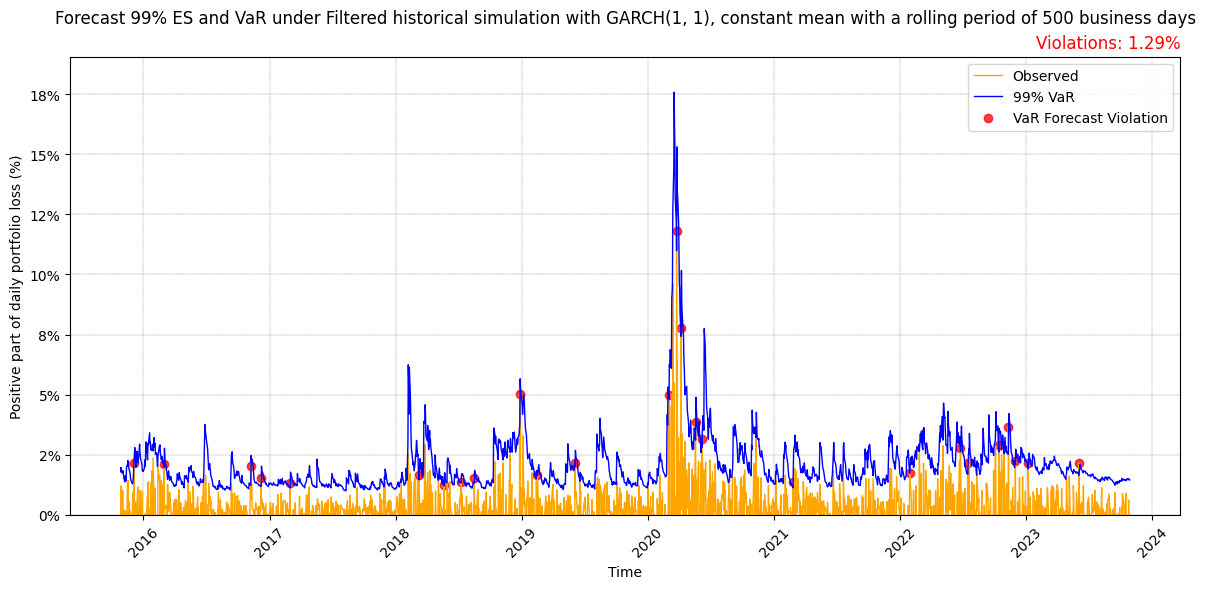

In [12]:
# Plotting the VaR violation at 99% level
violation_index_2 = [True if a > b else False for a, b in zip(loss_risk, VaR_arr_99)]
plt.figure(figsize=(12, 6))
plt.plot(time_arr_risk, loss_risk, label="Observed", linewidth=1, color="orange")
plt.plot(time_arr_risk, VaR_arr_99, label="99% VaR", linewidth=1, color="blue")
plt.scatter(time_arr_risk[violation_index_2], loss_risk[violation_index_2], color='red', alpha=0.75, label='VaR Forecast Violation')
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
# Adding title, labels, and legend
# plt.title("Filtered historical simulation with GARCH(1, 1), constant mean (500 business days rolling window)")
plt.title("Forecast 99% ES and VaR under Filtered historical simulation with GARCH(1, 1), constant mean with a rolling period of 500 business days\n", y = 1.01)
plt.title("Violations: " + str(round(26/2015*100, 3)) + "%", loc='right', color='red')
plt.xlabel("Time")
plt.ylabel("Positive part of daily portfolio loss (%)")
plt.legend()
plt.ylim(0, None)
# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

In [13]:
# function for conducting hypothesis tests with respect to VaR
def hypothesis_test_VaR(loss_arr, VaR_arr, T, q=0.95, mode='unconditional'):
    """
    Function for conducting hypothesis tests with respect to VaR.
    Input:
    loss_arr: the numpy array of loss of the portfolio (length: N).
    VaR_arr: the numpy array of VaR using a rolling window method (length: N-T).
    T: size of rolling window.
    q: the quantile level for the test.
    mode: 'unconditional' for unconditional coverage test, and 'independence' for 
    independence test.
    Output:
    p_value: the p_value of the test
    """
    loss_reduced = np.array(loss_arr[T:])
    # VaR violations
    I_arr = np.array([1 if a > b else 0 for a, b in zip(loss_reduced, VaR_arr)])
    violation_tuple = tuple((np.sum(I_arr), len(loss_reduced), np.sum(I_arr)/len(loss_reduced)))

    # unconditional coverage
    if mode == 'unconditional' or mode == 'joint':
        pi_hat = np.sum(I_arr) / len(I_arr)
        val_tmp = 1
        for p in range(len(I_arr)):
            val_tmp = val_tmp * (q**(1-I_arr[p]) * (1-q)**(I_arr[p])) / ((1-pi_hat)**(1-I_arr[p]) * pi_hat**(I_arr[p]))
        LR_uc = -2 * np.log(val_tmp)
        if mode == 'unconditional':
            p_value = 1 - chi2.cdf(LR_uc, 1)
            return violation_tuple, LR_uc, p_value

    # independence test
    if mode == 'independence' or mode == 'joint':
        val_00 = 0
        val_01 = 0
        val_10 = 0
        val_11 = 0
        for r in range(1, len(I_arr)):
            if I_arr[r-1] == 0 and I_arr[r] == 0:
                val_00 += 1
            elif I_arr[r-1] == 0 and I_arr[r] == 1:
                val_01 += 1
            elif I_arr[r-1] == 1 and I_arr[r] == 0:
                val_10 += 1
            elif I_arr[r-1] == 1 and I_arr[r] == 1:
                val_11 += 1
        T_tuple = (val_00, val_01, val_10, val_11)
        if val_11 == 0:
            val_11 = 0.00001
            print("No consecutive exceedances!")

        pi_11_hat = val_11 / (val_10 + val_11)
        pi_01_hat = val_01 / (val_00 + val_01)
        pi_hat = np.sum(I_arr) / len(I_arr)

        val_tmp = ((1-pi_hat)**(val_00 + val_10) * (pi_hat)**(val_01 + val_11)) / ((1-pi_01_hat)**val_00 * pi_01_hat**val_01 * (1-pi_11_hat)**val_10 * pi_11_hat**val_11)
        LR_ind = -2 * np.log(val_tmp)
        if mode == 'independence':
            p_value = 1 - chi2.cdf(LR_ind, 1)
            return violation_tuple, T_tuple, LR_ind, p_value

    if mode == 'joint':
        LR_joint = LR_uc + LR_ind
        p_value = 1 - chi2.cdf(LR_joint, 2)
        return LR_joint, p_value

In [14]:
# unconditional coverage test of 95% level
violation_tuple1, LR_uc1, p_list1 = hypothesis_test_VaR(x, VaR_arr_95, 500, q=0.95)
# unconditional coverage test of 99% level
violation_tuple2, LR_uc2, p_list2 = hypothesis_test_VaR(x, VaR_arr_99, 500, q=0.99)
# independence test of 95% level
violation_tuple3, T_tuple3, LR_uc3, p_list3 = hypothesis_test_VaR(x, VaR_arr_95, 500, q=0.95, mode='independence')
# independence test of 99% level
violation_tuple4, T_tuple4, LR_uc4, p_list4 = hypothesis_test_VaR(x, VaR_arr_99, 500, q=0.99, mode='independence')
# joint test of 95% level
p_joint_95 = hypothesis_test_VaR(x, VaR_arr_95, 500, q=0.95, mode='joint')
# joint test of 99% level
p_joint_99 = hypothesis_test_VaR(x, VaR_arr_99, 500, q=0.99, mode='joint')

No consecutive exceedances!
No consecutive exceedances!


In [15]:
violation_tuple1, LR_uc1, p_list1

((103, 2015, 0.0511166253101737), 0.052523880652836835, 0.8187283243755377)

In [16]:
violation_tuple2, LR_uc2, p_list2

((26, 2015, 0.012903225806451613), 1.5715692002708934, 0.2099792740752563)

In [17]:
violation_tuple3, T_tuple3, LR_uc3, p_list3

((103, 2015, 0.0511166253101737),
 (1810, 101, 101, 2),
 2.8835483331381524,
 0.08948862716080119)

In [18]:
violation_tuple4, T_tuple4, LR_uc4, p_list4

((26, 2015, 0.012903225806451613),
 (1962, 26, 26, 0),
 0.679877946345947,
 0.4096287560198212)

In [19]:
p_joint_95

(2.936072213790989, 0.23037747794909347)

In [20]:
p_joint_99

(2.25144714661684, 0.3244176424652142)

In [21]:
# function for conducting hypothesis tests with respect to ES
def hypothesis_test_ES(loss_arr, VaR_arr, ES_arr, T):
    """
    Function for conducting hypothesis tests with respect to VaR.
    Input:
    loss_arr: the numpy array of loss of the portfolio (length: N).
    VaR_arr: the numpy array of VaR using a rolling window method (length: N-T).
    T: size of rolling window.
    q: the quantile level for the test.
    mode: 'unconditional' for unconditional coverage test, and 'independence' for 
    independence test.
    Output:
    p_value: the p_value of the test
    """
    loss_reduced = np.array(loss_arr[T:])
    # VaR violations
    I_arr = np.array([1 if a > b else 0 for a, b in zip(loss_reduced, VaR_arr)])
    e_arr = (loss_reduced - ES_arr) * I_arr
    # violation_tuple = tuple((np.sum(I_arr), len(loss_reduced), np.sum(I_arr)/len(loss_reduced)))
    val_tmp_1 = np.sum(e_arr)
    val_tmp_2 = np.sqrt(np.sum(e_arr**2))
    z = val_tmp_1 / val_tmp_2
    p_value = 1 - norm.cdf(z)

    return z, p_value

In [22]:
# backtest ES at level 95%
z1, p_val_1 = hypothesis_test_ES(x, VaR_arr_95, ES_arr_95, 500)
# backtest ES at level 99%
z2, p_val_2 = hypothesis_test_ES(x, VaR_arr_99, ES_arr_99, 500)

In [23]:
z1, p_val_1

(0.5205017008027484, 0.30135697138529505)

In [24]:
z2, p_val_2

(0.1925837885025832, 0.4236424710767488)